# Predição de Desempenho Acadêmico no EBTT-UFPB
## Aluno, Professor e Currículo como Preditores de Sucesso

**Disciplina:** Aprendizagem de Máquina Supervisionada  
**Dados:** SIGAA/UFPB — CPT-ETS e CAVN  
**Entrega:** Parcial — Análise Exploratória + Experimentos Iniciais de Modelagem

---

### Estrutura do Notebook
1. Configuração do Ambiente
2. Carregamento e Inspeção dos Dados
3. Integração das Tabelas
4. Definição da Variável-Alvo
5. Análise Exploratória de Dados (EDA)
6. Pré-processamento e Feature Engineering
7. Modelagem Supervisionada
8. Comparação dos Modelos
9. Interpretabilidade
10. Conclusões Parciais e Próximos Passos

## Definição do Problema

Este projeto tem como objetivo desenvolver um modelo de machine learning capaz de **predizer o desempenho acadêmico dos discentes no âmbito do EBTT-UFPB**, considerando o ecossistema de aprendizagem composto por três dimensões principais: aluno, professor e currículo.

Trata-se de um problema de **classificação**, no qual se busca identificar padrões que permitam classificar os estudantes quanto ao seu desempenho acadêmico (por exemplo, aprovação ou reprovação em componentes curriculares).

Para isso, foram integradas diferentes bases de dados institucionais, incluindo:
- Informações dos discentes (perfil acadêmico e histórico)
- Dados de matrículas (trajetória acadêmica)
- Componentes curriculares (estrutura das disciplinas)
- Cursos (organização curricular)
- Docentes (características dos professores)

A hipótese central do projeto é que o desempenho acadêmico não depende apenas do aluno, mas é influenciado pela interação entre fatores individuais, características do corpo docente e estrutura curricular.

Dessa forma, o modelo proposto busca capturar essas relações para gerar previsões que possam subsidiar ações institucionais voltadas à melhoria do desempenho e redução de riscos acadêmicos.

## 1. Configuração do Ambiente

In [1]:

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.dummy import DummyClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay
)

SEED = 42
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

print('Ambiente configurado.')
import sklearn; print(f'sklearn {sklearn.__version__} | pandas {pd.__version__}')

Ambiente configurado.
sklearn 1.8.0 | pandas 3.0.1


## 2. Carregamento e Inspeção dos Dados

In [2]:
DATA_PATH = 'dados/'

discentes   = pd.read_parquet(DATA_PATH + 'discentes.parquet')
docentes    = pd.read_parquet(DATA_PATH + 'docentes.parquet')
matriculas  = pd.read_parquet(DATA_PATH + 'matriculas.parquet')
componentes = pd.read_parquet(DATA_PATH + 'componentes.parquet')
cursos      = pd.read_parquet(DATA_PATH + 'cursos.parquet')

datasets = {
    'discentes': discentes, 'docentes': docentes,
    'matriculas': matriculas, 'componentes': componentes, 'cursos': cursos
}

print(f'{"Dataset":<15} {"Linhas":>10} {"Colunas":>10}')
print('-' * 38)
for nome, df in datasets.items():
    print(f'{nome:<15} {df.shape[0]:>10,} {df.shape[1]:>10}')

Dataset             Linhas    Colunas
--------------------------------------
discentes            7,707         21
docentes               348         11
matriculas         426,753          5
componentes            998         22
cursos               1,310         19


In [3]:
for nome, df in datasets.items():
    print(f'\n{"="*55}\n  {nome.upper()}\n{"="*55}')
    print(df.dtypes.to_string())
    nulos = df.isnull().sum()
    nulos = nulos[nulos > 0]
    print('\n  Valores nulos:')
    if len(nulos):
        for col, n in nulos.items():
            print(f'    {col}: {n} ({n/len(df)*100:.1f}%)')
    else:
        print('    Nenhum.')
    display(df.head(3))


  DISCENTES
id_discente                     object
sexo                            object
estado_civil                    object
raca_declarada                  object
discente_nivel                  object
id_curso                         int64
id_curriculo                   float64
id_estrutura_curricular          int64
ano_ingresso                     int64
periodo_ingresso                 int64
status_discente                 object
forma_ingresso                  object
quantidade_membros_familia     float64
ch_integralizada               float64
ch_pendente                    float64
media_geral                    float64
ano_nascimento                 float64
faixa_renda_familiar          category
uf_titulo_eleitor_pb           float64
uf_naturalidade_pb             float64
pais_origem_br                 float64

  Valores nulos:
    id_curriculo: 7707 (100.0%)
    quantidade_membros_familia: 5587 (72.5%)
    ch_integralizada: 1871 (24.3%)
    ch_pendente: 1871 (24.3%)
    medi

,id_discente,sexo,estado_civil,raca_declarada,discente_nivel,id_curso,id_curriculo,id_estrutura_curricular,ano_ingresso,periodo_ingresso,...,forma_ingresso,quantidade_membros_familia,ch_integralizada,ch_pendente,media_geral,ano_nascimento,faixa_renda_familiar,uf_titulo_eleitor_pb,uf_naturalidade_pb,pais_origem_br
0,1169287803480640,M,Solteiro(a),Nao_informado,T,2558681,NaN,25587020,2016,2,...,PROCESSO SELETIVO,NaN,68.0,1432.0,0.93,1994.0,NaN,NaN,1.0,1.0
1,8959954670178323,F,Solteiro(a),Nao_informado,T,1958830,NaN,23647550,2016,2,...,PROCESSO SELETIVO,NaN,NaN,NaN,0.00,1997.0,NaN,1.0,1.0,1.0
2,9718041069456731,F,Solteiro(a),Negra,T,31496451,NaN,319171030,2023,1,...,PROCESSO SELETIVO,NaN,240.0,0.0,9.05,1970.0,NaN,NaN,1.0,1.0



  DOCENTES
id_pessoa              object
sexo                   object
tipo_vinculo           object
sigla_departamento     object
nome_departamento      object
sigla_centro           object
nome_centro            object
situacao               object
cargo                  object
ano_admissao          float64
ano_desligamento      float64

  Valores nulos:
    ano_admissao: 6 (1.7%)
    ano_desligamento: 131 (37.6%)


,id_pessoa,sexo,tipo_vinculo,sigla_departamento,nome_departamento,sigla_centro,nome_centro,situacao,cargo,ano_admissao,ano_desligamento
0,5986743761005378,F,DE,CPT-DRPAS,"CPT-ETS - DEPARTAMENTO DE REGISTRO, PROMOÇÃO E...",CPT-ETS,CENTRO PROFISSIONAL E TECNOLÓGICO - ESCOLA TÉC...,Colaborador PCCTAE,PROFESSOR ENS BASICO TECN TECNOLOGICO,2020.0,2024.0
1,6486331404889296,M,DE,PROEX,PRÓ-REITORIA DE EXTENSÃO (PROEX),UFPB.,UNIVERSIDADE FEDERAL DA PARAÍBA,Colaborador PCCTAE,PROFESSOR ENS BASICO TECN TECNOLOGICO,2022.0,2025.0
2,9067115124174644,F,DE,CCHSA-DCBS,CCHSA - DEPARTAMENTO DE CIÊNCIAS BÁSICAS E SOC...,CCHSA,CENTRO DE CIÊNCIAS HUMANAS SOCIAIS E AGRÁRIAS ...,Colaborador PCCTAE,PROF DO ENSINO BASICO TEC TECNOLOGICO,2018.0,2019.0



  MATRICULAS
id_discente      object
id_disciplina     int64
ano              object
periodo          object
situacao         object

  Valores nulos:
    Nenhum.


,id_discente,id_disciplina,ano,periodo,situacao
0,9519063299906826,25772,2020,1,APROVADO
1,9519063299906826,25774,2020,1,REPROVADO
2,9519063299906826,25773,2020,1,REPROVADO



  COMPONENTES
id_disciplina                            int64
id_detalhe                               int64
nome                                    object
ch_aula                                  int64
ch_laboratorio                           int64
ch_total                                 int64
cr_aula                                  int64
cr_laboratorio                           int64
cr_estagio                               int64
ch_ead                                   int64
sigla_departamento                      object
nivel_componente_curricular             object
sigla_academica                         object
nome_departamento                       object
sigla_centro                            object
nome_centro                             object
qtd_max_matriculas                       int64
codigo_componente_curricular            object
nome_componete_curricular               object
descricao_tipo_componente_curricular    object
excluir_avaliacao_institucional           boo

,id_disciplina,id_detalhe,nome,ch_aula,ch_laboratorio,ch_total,cr_aula,cr_laboratorio,cr_estagio,ch_ead,...,sigla_academica,nome_departamento,sigla_centro,nome_centro,qtd_max_matriculas,codigo_componente_curricular,nome_componete_curricular,descricao_tipo_componente_curricular,excluir_avaliacao_institucional,ativo
0,18066,2364646,NOÇÕES DE PRIMEIROS SOCORROS,30,0,30,2,0,0,0,...,ETS,CPT-ETS - COORDENAÇÃO ACADÊMICA GERAL DE CURSO...,CPT-ETS,CENTRO PROFISSIONAL E TECNOLÓGICO - ESCOLA TÉC...,1,TETS0001,NOÇÕES DE PRIMEIROS SOCORROS,DISCIPLINA,False,True
1,18069,2364635,NOÇÕES DE ANATOMIA E FISIOLOGIA HUMANA,40,0,40,2,0,0,0,...,ETS,CPT-ETS - COORDENAÇÃO ACADÊMICA GERAL DE CURSO...,CPT-ETS,CENTRO PROFISSIONAL E TECNOLÓGICO - ESCOLA TÉC...,1,TETS0002,NOÇÕES DE ANATOMIA E FISIOLOGIA HUMANA,DISCIPLINA,False,True
2,18070,2741620,"NOÇÕES DE MICROBIOLOGIA, PARASITOLOGIA E IMUNO...",10,30,40,2,0,0,0,...,ETS,CPT-ETS - COORDENAÇÃO ACADÊMICA GERAL DE CURSO...,CPT-ETS,CENTRO PROFISSIONAL E TECNOLÓGICO - ESCOLA TÉC...,1,TETS0003,"NOÇÕES DE MICROBIOLOGIA, PARASITOLOGIA E IMUNO...",DISCIPLINA,False,True



  CURSOS
id_curso                            int64
curso_nome                         object
curso_unidade_nome                 object
campus                             object
curso_ativo                          bool
curso_grande_area_conhecimento    float64
id_estrutura_curricular             int64
codigo_emec                       float64
turno_estrutura_curricular         object
periodo                            object
estrutura_curricular_ativo           bool
carga_horaria                       int64
id_modulo                           int64
codigo                             object
modulo                             object
carga_horaria_modulo                int64
ordem_oferta_modulo               float64
id_disciplina                       int64
codigo_disciplina                  object

  Valores nulos:
    curso_grande_area_conhecimento: 1310 (100.0%)
    codigo_emec: 1310 (100.0%)
    ordem_oferta_modulo: 617 (47.1%)


,id_curso,curso_nome,curso_unidade_nome,campus,curso_ativo,curso_grande_area_conhecimento,id_estrutura_curricular,codigo_emec,turno_estrutura_curricular,periodo,estrutura_curricular_ativo,carga_horaria,id_modulo,codigo,modulo,carga_horaria_modulo,ordem_oferta_modulo,id_disciplina,codigo_disciplina
0,31102902,TÉCNICO DE NÍVEL MÉDIO EM GUIA DE TURISMO INTE...,CCHSA - CAVN - COLÉGIO AGRÍCOLA VIDAL DE NEGRE...,Bananeiras,True,NaN,311029220,NaN,Noturno,N,True,2000,31102776,MOD0069,BASE NACIONAL COMUM CURRICULAR (BNCC),1200,1.0,27342,CAVN00112
1,31102902,TÉCNICO DE NÍVEL MÉDIO EM GUIA DE TURISMO INTE...,CCHSA - CAVN - COLÉGIO AGRÍCOLA VIDAL DE NEGRE...,Bananeiras,True,NaN,311029220,NaN,Noturno,N,True,2000,31102776,MOD0069,BASE NACIONAL COMUM CURRICULAR (BNCC),1200,1.0,28736,CAVN00165
2,31102902,TÉCNICO DE NÍVEL MÉDIO EM GUIA DE TURISMO INTE...,CCHSA - CAVN - COLÉGIO AGRÍCOLA VIDAL DE NEGRE...,Bananeiras,True,NaN,311029220,NaN,Noturno,N,True,2000,31102776,MOD0069,BASE NACIONAL COMUM CURRICULAR (BNCC),1200,1.0,28737,CAVN00166


In [4]:
print('Situacoes nas matriculas:')
print(matriculas['situacao'].value_counts().to_string())
print(f'\nAnos: {sorted(matriculas["ano"].unique())}')

Situacoes nas matriculas:
situacao
APROVADO               318849
CANCELADO               32931
REPROVADO               25175
EXCLUIDA                14846
REP. MEDIA E FALTA      12986
MATRICULADO             11770
TRANCADO                 4560
APROVEITADO              4197
DISPENSADO                470
REP. FALTA                411
DESISTENCIA               322
TRANSFERIDO               221
INDEFERIDO                  8
APROV. C/ DISTINÇÃO         7

Anos: ['2004', '2005', '2006', '2009', '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024', '2025']


In [5]:
print(matriculas['ano'].value_counts().to_string())

ano
2023    156103
2024     84018
2020     49157
2018     30385
2017     26443
2022     21629
2021     21459
2019     13881
2016     13405
2015      9942
2014       183
2013        71
2009        24
2025        18
2005        11
2004        10
2006         7
2012         6
2011         1


In [6]:
componentes["nome_componete_curricular"].unique()

array(['NOÇÕES DE PRIMEIROS SOCORROS',
       'NOÇÕES DE ANATOMIA E FISIOLOGIA HUMANA',
       'NOÇÕES DE MICROBIOLOGIA, PARASITOLOGIA E IMUNOLOGIA',
       'EDUCAÇÃO EM SAÚDE', 'PSICOLOGIA APLICADA À SAÚDE',
       'ÉTICA EM SAÚDE', 'INTRODUÇÃO À MICROINFORMÁTICA',
       'ANATOMIA E FISIOLOGIA DA CABEÇA E PESCOÇO',
       'ÉTICA PROFISSIONAL E LEGISLAÇÃO TRABALHISTA', 'BIOSSEGURANÇA',
       'ANATOMIA E ESCULTURA DENTAL I E II',
       'ANATOMIA E ESCULTURA DENTAL II', 'MATERIAIS DENTÁRIOS',
       'PRÓTESE FIXA I', 'PRÓTESE FIXA II', 'PRÓTESE FIXA III',
       'PRÓTESE FIXA IV', 'PRÓTESE PARCIAL REMOVÍVEL',
       'PRÓTESE TOTAL I E II', 'INTRODUÇÃO À PRÓTESE DENTÁRIA',
       'PRÓTESE ORTODÔNTICA', 'MOLDES E MODELOS', 'OCLUSÃO DENTAL',
       'ADMINISTRAÇÃO', 'ESTÁGIO SUPERVISIONADO OCLUSÃO',
       'NOÇÕES DE ANATOMIA E FISIOLOGIA DO SISTEMA ESTOMATOGNÁTICO',
       'ÉTICA E LEGISLAÇÃO',
       'BIOSSEGURANÇA E ERGONOMIA NO LABORATÓRIO DE PRÓTESE DENTÁRIA',
       'INICIAÇÃO À PES

In [7]:
docentes.info()

<class 'pandas.DataFrame'>
RangeIndex: 348 entries, 0 to 347
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id_pessoa           348 non-null    object 
 1   sexo                348 non-null    object 
 2   tipo_vinculo        348 non-null    object 
 3   sigla_departamento  348 non-null    object 
 4   nome_departamento   348 non-null    object 
 5   sigla_centro        348 non-null    object 
 6   nome_centro         348 non-null    object 
 7   situacao            348 non-null    object 
 8   cargo               348 non-null    object 
 9   ano_admissao        342 non-null    float64
 10  ano_desligamento    217 non-null    float64
dtypes: float64(2), object(9)
memory usage: 30.0+ KB


In [8]:
docentes['cargo'].value_counts()

cargo
PROFESSOR ENS BASICO TECN TECNOLOGICO       309
PROF DO ENSINO BASICO TEC TECNOLOGICO        36
PROF ENS BAS TEC TECNOLOGICO - VISITANTE      2
PROF ENS BAS TEC TECNOLOGICO-SUBSTITUTO       1
Name: count, dtype: int64

In [9]:
docentes['situacao'].value_counts()

situacao
Ativo Permanente                     142
Aposentado                           121
Instituidor de Pensão                 75
Colaborador PCCTAE                     3
Cedido                                 2
Professor Visitante                    2
Exercicio provisorio                   1
Professor Substituto                   1
Requisitado por Força de Trabalho      1
Name: count, dtype: int64

## 3. Integração das Tabelas

```
matriculas
  ├── id_discente   ──► discentes   (perfil do aluno)
  └── id_disciplina ──► componentes (currículo)
                            └── sigla_departamento ──► docentes (agregado por dept.)
```

### limpando discentes

In [10]:
m = (
    discentes["forma_ingresso"]
    .astype(str)
    .str.strip()
    .str.upper()
    .eq("PROCESSO SELETIVO")
)
discentes["forma_ingresso"] = np.where(m, "PROCESSO SELETIVO", "outros")


In [11]:
discentes.info()

<class 'pandas.DataFrame'>
RangeIndex: 7707 entries, 0 to 7706
Data columns (total 21 columns):
 #   Column                      Non-Null Count  Dtype   
---  ------                      --------------  -----   
 0   id_discente                 7707 non-null   object  
 1   sexo                        7707 non-null   object  
 2   estado_civil                7707 non-null   object  
 3   raca_declarada              7707 non-null   object  
 4   discente_nivel              7707 non-null   object  
 5   id_curso                    7707 non-null   int64   
 6   id_curriculo                0 non-null      float64 
 7   id_estrutura_curricular     7707 non-null   int64   
 8   ano_ingresso                7707 non-null   int64   
 9   periodo_ingresso            7707 non-null   int64   
 10  status_discente             7707 non-null   object  
 11  forma_ingresso              7707 non-null   str     
 12  quantidade_membros_familia  2120 non-null   float64 
 13  ch_integralizada            5

In [12]:
cols_num = discentes.select_dtypes(include=["number"]).columns
discentes[cols_num].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99])

,id_curso,id_curriculo,id_estrutura_curricular,ano_ingresso,periodo_ingresso,quantidade_membros_familia,ch_integralizada,ch_pendente,media_geral,ano_nascimento,uf_titulo_eleitor_pb,uf_naturalidade_pb,pais_origem_br
count,7.707000e+03,0.0,7.707000e+03,7707.000000,7707.000000,2120.000000,5836.000000,5836.000000,7042.000000,7704.000000,5944.000000,7681.000000,7707.000000
mean,9.753725e+06,NaN,1.396363e+08,2020.281951,1.501881,4.298113,923.295579,513.168609,5.809480,1991.290109,0.754879,0.779586,0.985079
std,1.084091e+07,NaN,1.170914e+08,2.798593,0.500029,25.634208,942.779275,787.616136,3.521833,60.897226,0.430195,0.414553,0.121247
min,1.958830e+06,NaN,1.958833e+07,2015.000000,1.000000,1.000000,15.000000,-510.000000,0.000000,1.000000,0.000000,0.000000,0.000000
1%,1.958830e+06,NaN,1.958833e+07,2015.000000,1.000000,1.000000,15.000000,-60.000000,0.000000,1962.000000,0.000000,0.000000,0.000000
5%,1.958830e+06,NaN,1.997135e+07,2015.000000,1.000000,1.000000,30.000000,-16.000000,0.000000,1972.000000,0.000000,0.000000,1.000000
50%,2.558681e+06,NaN,1.543249e+08,2021.000000,2.000000,3.000000,658.000000,90.000000,7.660000,1996.000000,1.000000,1.000000,1.000000
95%,3.116979e+07,NaN,3.153648e+08,2024.000000,2.000000,6.000000,3360.000000,1985.000000,9.510000,2005.000000,1.000000,1.000000,1.000000
99%,3.812166e+07,NaN,3.839984e+08,2024.000000,2.000000,8.000000,4045.000000,3945.000000,9.920000,2009.000000,1.000000,1.000000,1.000000
max,3.909537e+07,NaN,3.909541e+08,2024.000000,2.000000,890.000000,4105.000000,4030.000000,10.000000,2010.000000,1.000000,1.000000,1.000000


In [13]:
discentes["ch_integralizada"] = discentes["ch_integralizada"].fillna(0)
discentes["ch_pendente"] = discentes["ch_pendente"].fillna(0)

In [14]:
def mascara_outliers_iqr(s, k=1.5, apenas_superior=False):
    s = s.dropna()
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    if iqr == 0:
        return pd.Series(False, index=s.index)
    low, high = q1 - k * iqr, q3 + k * iqr
    if apenas_superior:
        return s > high
    return (s < low) | (s > high)

# exemplo: aplicar em discentes
k = 1.5
colunas = ["quantidade_membros_familia"]

for col in colunas:
    if col not in discentes.columns:
        continue
    mask = mascara_outliers_iqr(discentes[col], k=k, apenas_superior=False)
    # alinhar ao índice do dataframe (dropna remove índices no cálculo)
    mask = mask.reindex(discentes.index).fillna(False)
    discentes.loc[mask, col] = np.nan

# depois: imputar média como você combinou
for col in colunas:
    if col in discentes.columns:
        discentes[col] = discentes[col].fillna(discentes[col].median())

<Axes: >

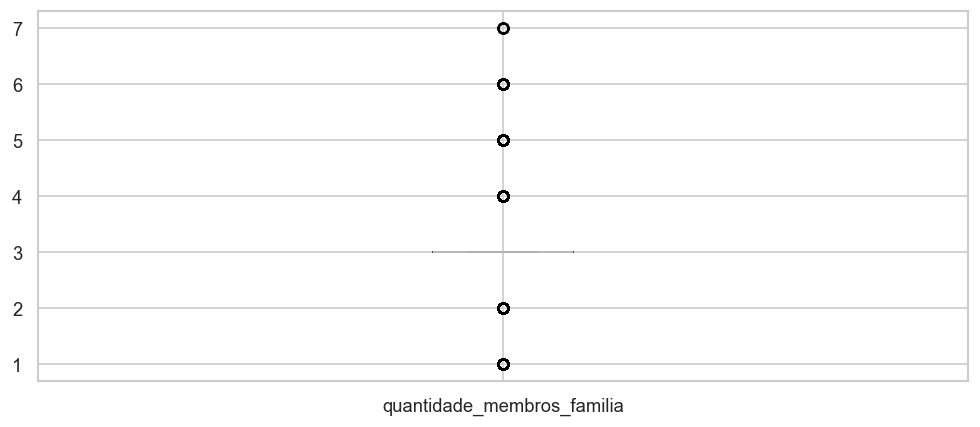

In [15]:
discentes.boxplot(column=["quantidade_membros_familia"], figsize=(10, 4))

In [16]:
c = discentes['faixa_renda_familiar']
if pd.api.types.is_categorical_dtype(c):
    if 'nulo' not in c.cat.categories:
        c = c.cat.add_categories(['nulo'])
    discentes['faixa_renda_familiar'] = c.fillna('nulo')
else:
    discentes['faixa_renda_familiar'] = c.fillna('nulo')

s = discentes["quantidade_membros_familia"]
# Faixas: exemplo — 1 pessoa, 2-3, 4-5, 6 ou mais (mude se quiser)
faixa = pd.cut(
    s,
    bins=[0, 1, 3, 5, np.inf],
    labels=["1", "2-3", "4-5", "6+"],
    include_lowest=True,
)

# Categoria para quem é nulo
discentes["faixa_membros_familia"] = faixa.astype("object").where(s.notna(), "nulo")

In [17]:
colunas_discente = ["id_discente", "sexo", "ano_nascimento", "estado_civil", "raca_declarada", 
                    "id_curso", "id_estrutura_curricular",  'media_geral',
                    "ch_integralizada", "ch_pendente", "faixa_renda_familiar", 
                    'periodo_ingresso', 'forma_ingresso', 'faixa_membros_familia', 'ano_ingresso']

discente_limpo = discentes.copy()[colunas_discente].drop_duplicates()

In [18]:
discente_limpo

,id_discente,sexo,ano_nascimento,estado_civil,raca_declarada,id_curso,id_estrutura_curricular,media_geral,ch_integralizada,ch_pendente,faixa_renda_familiar,periodo_ingresso,forma_ingresso,faixa_membros_familia,ano_ingresso
0,1169287803480640,M,1994.0,Solteiro(a),Nao_informado,2558681,25587020,0.93,68.0,1432.0,nulo,2,PROCESSO SELETIVO,2-3,2016
1,8959954670178323,F,1997.0,Solteiro(a),Nao_informado,1958830,23647550,0.00,0.0,0.0,nulo,2,PROCESSO SELETIVO,2-3,2016
2,9718041069456731,F,1970.0,Solteiro(a),Negra,31496451,319171030,9.05,240.0,0.0,nulo,1,PROCESSO SELETIVO,2-3,2023
3,9657337360405103,F,1995.0,Outro,Negra,3926060,39260790,9.00,1200.0,0.0,ate_1k,2,PROCESSO SELETIVO,2-3,2018
4,8032369354468776,F,2000.0,Solteiro(a),Negra,2663867,29380940,7.27,1305.0,0.0,nulo,1,PROCESSO SELETIVO,2-3,2018
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7702,6772894364296419,F,1973.0,Casado(a),Negra,38121652,382834570,0.00,0.0,0.0,ate_1k,2,PROCESSO SELETIVO,2-3,2024
7703,4630598849846245,F,1977.0,Solteiro(a),Negra,1958830,304663930,8.47,390.0,1215.0,ate_1k,2,PROCESSO SELETIVO,1,2024
7704,8732507845467422,F,1983.0,Solteiro(a),Negra,1958830,23647550,0.00,0.0,0.0,ate_1k,2,PROCESSO SELETIVO,1,2016
7705,5488824399274928,F,1987.0,Casado(a),Branca,1958830,23647550,9.21,1996.0,-196.0,nulo,1,PROCESSO SELETIVO,2-3,2021


### limpando docentes

In [108]:
docentes.info()

<class 'pandas.DataFrame'>
RangeIndex: 348 entries, 0 to 347
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id_pessoa           348 non-null    object 
 1   sexo                348 non-null    object 
 2   tipo_vinculo        348 non-null    object 
 3   sigla_departamento  348 non-null    object 
 4   nome_departamento   348 non-null    object 
 5   sigla_centro        348 non-null    object 
 6   nome_centro         348 non-null    object 
 7   situacao            348 non-null    object 
 8   cargo               348 non-null    object 
 9   ano_admissao        342 non-null    float64
 10  ano_desligamento    217 non-null    float64
 11  _fem                348 non-null    int64  
 12  _vinc_DE            348 non-null    int64  
 13  _vinc_T40           348 non-null    int64  
 14  _vinc_T20           348 non-null    int64  
 15  tipo_vinculo_label  348 non-null    str    
dtypes: float64(2), int6

In [109]:
doc = docentes.copy()
doc['ano_admissao'] = pd.to_numeric(doc['ano_admissao'], errors='coerce')
doc['ano_desligamento'] = pd.to_numeric(doc['ano_desligamento'], errors='coerce')

In [110]:
agg_map = {'id_pessoa': 'count', 'ano_admissao': 'median'}
if 'sexo' in doc.columns:
  doc['_fem'] = (doc['sexo'] == 'F').astype(int)
  agg_map['_fem'] = 'mean'
if 'tipo_vinculo' in doc.columns:
  VINCULO_MAP = {
      'DE': 'DE (Dedicação Exclusiva)',
      'T40': 'T40 (40 horas semanais)',
      'T20': 'T20 (20 horas semanais)',
  }
  tipo_vinculo_normalizado = doc['tipo_vinculo'].astype(str).str.strip().str.upper()
  doc['tipo_vinculo_label'] = tipo_vinculo_normalizado.map(VINCULO_MAP).fillna(
      doc['tipo_vinculo'].astype(str)
  )
  for codigo_vinculo in VINCULO_MAP:
      doc[f'_vinc_{codigo_vinculo}'] = (tipo_vinculo_normalizado == codigo_vinculo).astype(int)
      agg_map[f'_vinc_{codigo_vinculo}'] = 'mean'

colunas_para_espelhar = ['_fem', '_vinc_DE', '_vinc_T40', '_vinc_T20', 'tipo_vinculo_label']
for coluna in colunas_para_espelhar:
  if coluna in doc.columns:
      docentes[coluna] = doc[coluna].values


In [111]:
ANOS_REF = list(matriculas['ano'].unique())
colunas_geograficas = [c for c in ('sigla_centro', 'sigla_departamento') if c in doc.columns]
if 'sigla_departamento' not in colunas_geograficas:
  raise ValueError('A base de docentes precisa da coluna sigla_departamento.')
pares_centro_departamento = doc[colunas_geograficas].drop_duplicates()
grade_ano_referencia = pares_centro_departamento.merge(
  pd.DataFrame({'ano': ANOS_REF}), how='cross'
)
grade_ano_referencia['ano'] = pd.to_numeric(grade_ano_referencia['ano'], errors='coerce')


chaves_merge_doc = [
  c for c in ('sigla_departamento', 'sigla_centro')
  if c in doc.columns and c in grade_ano_referencia.columns
]
grade_com_cadastro_docente = grade_ano_referencia.merge(doc, on=chaves_merge_doc, how='inner')

# ver se o docente estava ativo naquele ano
ano_admissao = grade_com_cadastro_docente['ano_admissao']
ano_desligamento = grade_com_cadastro_docente['ano_desligamento']
ano_referencia = grade_com_cadastro_docente['ano']
esta_ativo = (
  ano_admissao.notna()
  & (ano_admissao <= ano_referencia)
  & (ano_desligamento.isna() | (ano_desligamento > ano_referencia))
)
docentes_ativos = grade_com_cadastro_docente.loc[esta_ativo]

# agregar por departamento e ano apenas os professores ativos
chaves_agregacao = [
  c for c in ('sigla_centro', 'sigla_departamento', 'ano')
  if c in docentes_ativos.columns
]
docentes_limpo = (
  docentes_ativos.groupby(chaves_agregacao, as_index=False, dropna=False)
  .agg(agg_map)
  .rename(columns={
      'id_pessoa': 'total_docentes',
      '_fem': 'prop_feminino',
      '_vinc_DE': 'prop_de',
      '_vinc_T40': 'prop_t40',
      '_vinc_T20': 'prop_t20',
      'ano_admissao': 'ano_admissao_medio',
  })
)
docentes_limpo

,sigla_centro,sigla_departamento,ano,total_docentes,ano_admissao_medio,prop_feminino,prop_de,prop_t40,prop_t20
0,CCA,CCA-DCFS,2004,1,1984.0,1.0,1.0,0.0,0.0
1,CCA,CCA-DCFS,2005,1,1984.0,1.0,1.0,0.0,0.0
2,CCA,CCA-DCFS,2006,1,1984.0,1.0,1.0,0.0,0.0
3,CCA,CCA-DCFS,2009,1,1984.0,1.0,1.0,0.0,0.0
4,CCA,CCA-DCFS,2011,1,1984.0,1.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...
349,UFPB.,CS,2011,1,2007.0,1.0,1.0,0.0,0.0
350,UFPB.,CS,2012,1,2007.0,1.0,1.0,0.0,0.0
351,UFPB.,PROEX,2022,1,2022.0,0.0,1.0,0.0,0.0
352,UFPB.,PROEX,2023,1,2022.0,0.0,1.0,0.0,0.0


### limpando componentes

In [112]:
componentes.info()

<class 'pandas.DataFrame'>
RangeIndex: 998 entries, 0 to 997
Data columns (total 23 columns):
 #   Column                                Non-Null Count  Dtype 
---  ------                                --------------  ----- 
 0   id_disciplina                         998 non-null    int64 
 1   id_detalhe                            998 non-null    int64 
 2   nome                                  998 non-null    object
 3   ch_aula                               998 non-null    int64 
 4   ch_laboratorio                        998 non-null    int64 
 5   ch_total                              998 non-null    int64 
 6   cr_aula                               998 non-null    int64 
 7   cr_laboratorio                        998 non-null    int64 
 8   cr_estagio                            998 non-null    int64 
 9   ch_ead                                998 non-null    int64 
 10  sigla_departamento                    998 non-null    object
 11  nivel_componente_curricular           998 n

In [113]:
componentes['qtd_max_matriculas'].unique()

array([1])

In [114]:
componentes['nivel_componente_curricular'].unique()

array(['T'], dtype=object)

In [119]:
import json

with open("mapeamento_disciplinas.json", encoding="utf-8") as f:
    dados = json.load(f)

dicionario_areas = dados["dicionario_areas"]

componentes["area_conhecimento"] = componentes["nome_componete_curricular"].map(dicionario_areas)

In [120]:
colunas_componentes = ['id_disciplina', 'codigo_componente_curricular', 'area_conhecimento', 'ch_aula', 'ch_ead', 
                        'ch_laboratorio', 'ch_total', 'sigla_departamento', 'sigla_centro',
                        'nivel_componente_curricular','descricao_tipo_componente_curricular']

In [121]:
componentes_limpa = componentes.copy()[colunas_componentes].drop_duplicates()

In [118]:
componentes_limpa.head()

,id_disciplina,codigo_componente_curricular,area_conhecimento,ch_aula,ch_ead,ch_laboratorio,ch_total,sigla_departamento,sigla_centro,nivel_componente_curricular,descricao_tipo_componente_curricular
0,18066,TETS0001,Ciências da Saúde,30,0,0,30,CPT-ETS-COAGCEP,CPT-ETS,T,DISCIPLINA
1,18069,TETS0002,Ciências Biológicas,40,0,0,40,CPT-ETS-COAGCEP,CPT-ETS,T,DISCIPLINA
2,18070,TETS0003,Ciências Biológicas,10,0,30,40,CPT-ETS-COAGCEP,CPT-ETS,T,DISCIPLINA
3,18071,TETS0004,Ciências da Saúde,65,0,0,65,CPT-ETS-COAGCEP,CPT-ETS,T,DISCIPLINA
4,18072,TETS0005,Ciências Humanas e Sociais Aplicadas,50,0,0,50,CPT-ETS-COAGCEP,CPT-ETS,T,DISCIPLINA


## limpando cursos

In [122]:
cursos.info()

<class 'pandas.DataFrame'>
RangeIndex: 1310 entries, 0 to 1309
Data columns (total 19 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id_curso                        1310 non-null   int64  
 1   curso_nome                      1310 non-null   object 
 2   curso_unidade_nome              1310 non-null   object 
 3   campus                          1310 non-null   object 
 4   curso_ativo                     1310 non-null   bool   
 5   curso_grande_area_conhecimento  0 non-null      float64
 6   id_estrutura_curricular         1310 non-null   int64  
 7   codigo_emec                     0 non-null      float64
 8   turno_estrutura_curricular      1310 non-null   object 
 9   periodo                         1310 non-null   object 
 10  estrutura_curricular_ativo      1310 non-null   bool   
 11  carga_horaria                   1310 non-null   int64  
 12  id_modulo                       1310 non-null

In [123]:
cursos['carga_horaria'].unique()

array([2000, 1800, 4035, 2790, 1545, 4045, 1555, 1310, 1305, 1275,  800,
        945,  160, 1200, 1050, 3360, 3375, 1365, 1185, 1500, 1350, 1605,
       1110, 1410, 1245,  165,  810, 1345, 1495, 1320])

In [124]:
cursos_limpo = cursos.copy()[['id_curso', 'curso_nome', 'id_estrutura_curricular', 'id_disciplina', 'carga_horaria']]

### juntando as informações

In [125]:
matriculas['ano'] = pd.to_numeric(matriculas['ano'], errors="coerce")
docentes_limpo["ano"] = pd.to_numeric(docentes_limpo["ano"], errors="coerce")

In [126]:
df = (
  matriculas.merge(discente_limpo, on="id_discente", how="left", validate="m:1")
  .merge(componentes_limpa, on="id_disciplina", how="left", validate="m:1")
  .merge(cursos_limpo, on=["id_curso", "id_estrutura_curricular", "id_disciplina"], how="left", validate="m:1")
  .merge(
      docentes_limpo,
      on=["sigla_centro", "sigla_departamento", "ano"],
      how="left",
      validate="m:1",
  )
).dropna(subset='sexo')




In [127]:
df_teste_2 = (
  matriculas.merge(discente_limpo, on="id_discente", how="left", validate="m:1")
  .merge(componentes_limpa, on="id_disciplina", how="left", validate="m:1")
  .merge(cursos_limpo, on=["id_curso", "id_estrutura_curricular", "id_disciplina"], how="left", validate="m:1")
).dropna(subset='sexo')


In [128]:
df_teste_2.info()



<class 'pandas.DataFrame'>
Index: 164436 entries, 11 to 426752
Data columns (total 31 columns):
 #   Column                                Non-Null Count   Dtype   
---  ------                                --------------   -----   
 0   id_discente                           164436 non-null  object  
 1   id_disciplina                         164436 non-null  int64   
 2   ano                                   164436 non-null  int64   
 3   periodo                               164436 non-null  object  
 4   situacao                              164436 non-null  object  
 5   sexo                                  164436 non-null  object  
 6   ano_nascimento                        164388 non-null  float64 
 7   estado_civil                          164436 non-null  object  
 8   raca_declarada                        164436 non-null  object  
 9   id_curso                              164436 non-null  float64 
 10  id_estrutura_curricular               164436 non-null  float64 
 11  me

In [129]:
df_teste = df.copy().dropna(subset='total_docentes')

## o df de teste virou o principal

In [130]:
#df = df_teste.copy()
df = df_teste_2.copy()

In [131]:
df_teste['sigla_centro'].unique()

array(['CPT-ETS'], dtype=object)

In [132]:
df_teste.shape

(33009, 37)

In [133]:
df_teste['curso_nome'].value_counts()

curso_nome
TÉCNICO EM ENFERMAGEM                                10154
TÉCNICO EM ANÁLISES CLÍNICAS                          7434
TÉCNICO EM PRÓTESE DENTÁRIA                           6849
TÉCNICO EM CUIDADOS DE IDOSOS - PROEJA                3590
TÉCNICO EM CUIDADOS DE IDOSOS                         2216
TÉCNICO EM REGISTROS E INFORMAÇÕES EM SAÚDE - EaD      643
Name: count, dtype: int64

In [134]:
df_teste['ano'].value_counts()

ano
2021    7887
2020    5766
2018    5547
2019    5404
2017    4125
2016    3299
2015     981
Name: count, dtype: int64

In [135]:
df_teste['sigla_departamento'].unique()

array(['CPT-ETS-COAGCEP'], dtype=object)

In [136]:
docentes['sigla_centro'].unique()

array(['CPT-ETS', 'UFPB.', 'CCHSA', 'CE', 'REITORIA-', 'CTDR', 'CEAR',
       'CCA', 'CCTA', 'SRH-CRH', 'PROGEP', 'CCHLA.', 'PROGEP - CDP',
       'CCEN', 'CT', 'PROEX', 'PROGEP-CPGP', 'CCS', 'REITORIA- GR'],
      dtype=object)

In [137]:
componentes['sigla_centro'].unique()

array(['CPT-ETS', 'CCHSA'], dtype=object)

In [138]:
componentes['sigla_departamento'].unique()

array(['CPT-ETS-COAGCEP', 'CCHSA - CAVN'], dtype=object)

In [139]:
docentes['sigla_departamento'].unique()

array(['CPT-DRPAS', 'PROEX', 'CCHSA-DCBS', 'CPT-DDPLO', 'CCHSA - DCA',
       'CCHSA-DCSA', 'CE - DEB', 'CCHSA-DA', 'SSI', 'CCHSA - DA',
       'CCHSA-DGTA', 'CTDR-DTA', 'CEAR - DEER', 'CCHSA-DE', 'CCA-DZOOT',
       'CCTA - DECOM', 'CS', 'REITORIA- GR', 'SRH-DCS', 'CCA-DC',
       'CCHSA-DC', 'CE-CREESCOLA', 'CE-DC', 'PROGEP - CDP',
       'CPT-ETS-COAGCEP', 'CCHLA-DC', 'PROGEP - DPC', 'CCEN-DQ',
       'CCHLA - DLCV', 'CT-NUPPA', 'PRAC-CODEN', 'CT-DC', 'PROGEP-ATPLAN',
       'CCA-DCFS', 'CCTA - DM', 'PRPG-UFPB', 'UFPB.', 'PROGEP-CPACE',
       'PROGEP-DSP', 'CCS - DMINF', 'LTF', 'CCHSA-DTR', 'CCHSA - CAVN',
       'CCHLA - DSS'], dtype=object)

## 4. Definição da Variável-Alvo

| Valor | Classe | Situações |
|-------|--------|-----------|
| 1 | **Sucesso** | APROVADO, APROV. C/ DISTINÇÃO, DISPENSADO |
| 0 | **Insucesso** | REPROVADO, REPROVADO POR FALTA, CANCELADO, TRANCADO |

In [140]:
df['situacao'].value_counts()

situacao
APROVADO               103797
REPROVADO               18033
EXCLUIDA                12259
REP. MEDIA E FALTA       9858
MATRICULADO              7739
TRANCADO                 4527
APROVEITADO              4186
CANCELADO                2733
DISPENSADO                470
DESISTENCIA               301
REP. FALTA                297
TRANSFERIDO               221
INDEFERIDO                  8
APROV. C/ DISTINÇÃO         7
Name: count, dtype: int64

In [141]:
SITUACOES_SUCESSO = [
    'APROVADO',
    'APROV. C/ DISTINÇÃO',
    'DISPENSADO',
    'APROVEITADO',
]
SITUACOES_INSUCESSO = [
    'REPROVADO',
    'REP. MEDIA E FALTA',
    'REP. FALTA',
    'CANCELADO',
    'TRANCADO',
    'DESISTENCIA',
    'TRANSFERIDO',
    'EXCLUIDA',
    'INDEFERIDO',
]

SITUACOES_EXCLUIR_DO_MODELO = [
    'MATRICULADO',
]

situacoes_finais = SITUACOES_SUCESSO + SITUACOES_INSUCESSO
df_modelo = df[df['situacao'].isin(situacoes_finais)].copy()
df_modelo['target'] = df_modelo['situacao'].isin(SITUACOES_SUCESSO).astype(int)

vc = df_modelo['target'].value_counts()
print(f'Total (situacoes finais): {len(df_modelo):,}')
print(f'Sucesso   (1): {vc.get(1,0):,} ({vc.get(1,0)/len(df_modelo)*100:.1f}%)')
print(f'Insucesso (0): {vc.get(0,0):,} ({vc.get(0,0)/len(df_modelo)*100:.1f}%)')
ratio = vc.get(1,0) / max(vc.get(0,0), 1)
print(f'Razão S/I: {ratio:.2f}' + (' ⚠️ desbalanceado' if ratio > 3 else ''))

Total (situacoes finais): 156,697
Sucesso   (1): 108,460 (69.2%)
Insucesso (0): 48,237 (30.8%)
Razão S/I: 2.25


## 5. Análise Exploratória de Dados (EDA)

### 5.1 Dimensão Aluno

In [51]:
df.info()

<class 'pandas.DataFrame'>
Index: 164436 entries, 11 to 426752
Data columns (total 31 columns):
 #   Column                                Non-Null Count   Dtype   
---  ------                                --------------   -----   
 0   id_discente                           164436 non-null  object  
 1   id_disciplina                         164436 non-null  int64   
 2   ano                                   164436 non-null  int64   
 3   periodo                               164436 non-null  object  
 4   situacao                              164436 non-null  object  
 5   sexo                                  164436 non-null  object  
 6   ano_nascimento                        164388 non-null  float64 
 7   estado_civil                          164436 non-null  object  
 8   raca_declarada                        164436 non-null  object  
 9   id_curso                              164436 non-null  float64 
 10  id_estrutura_curricular               164436 non-null  float64 
 11  me

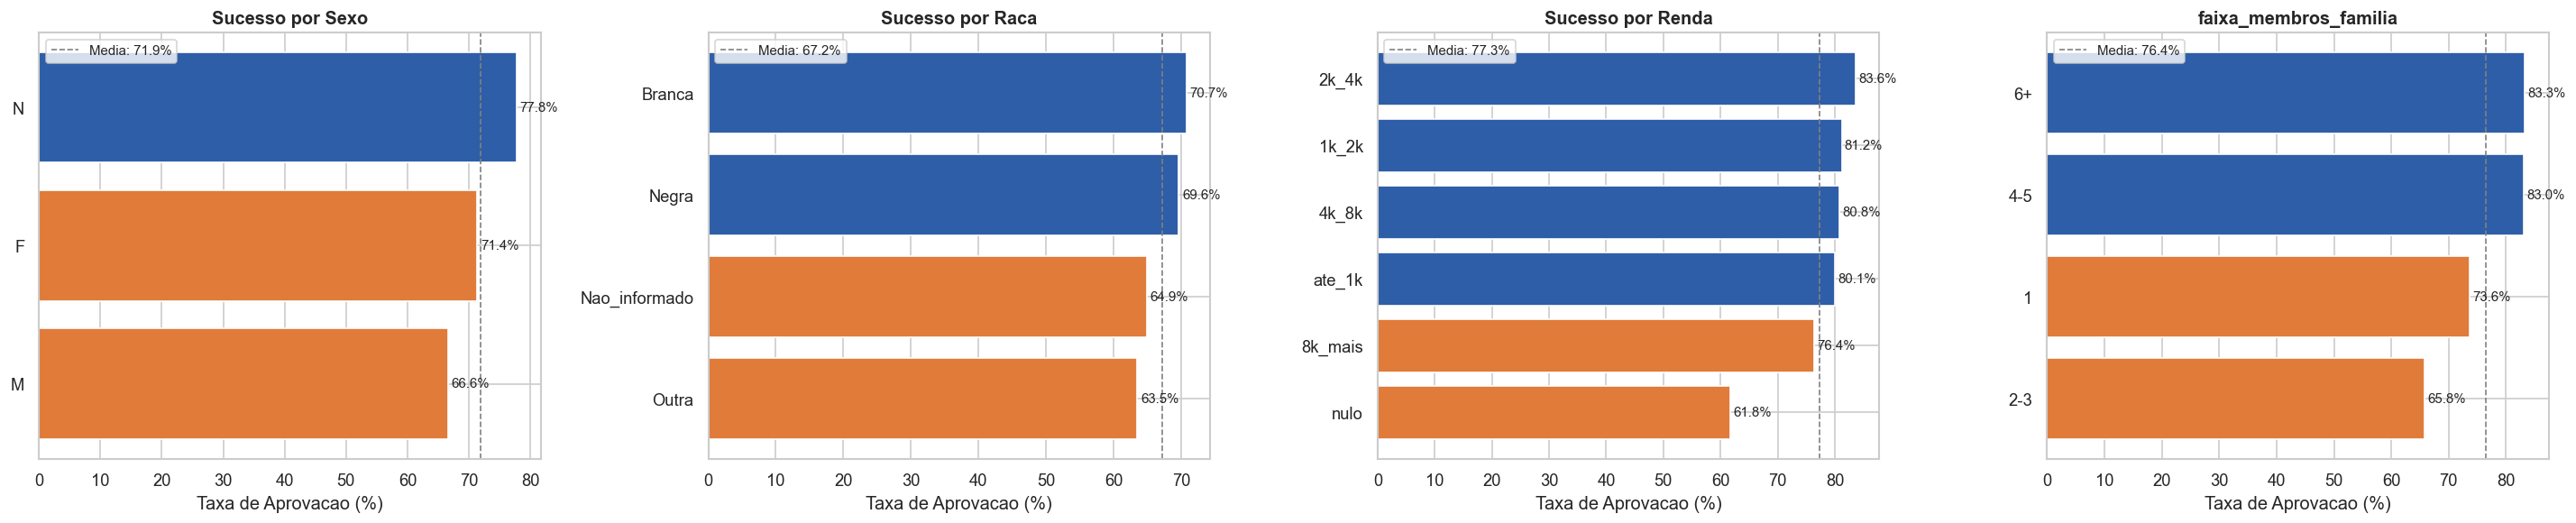

In [52]:
cols_perfil = [c for c in ['sexo', 'raca_declarada', 'faixa_renda_familiar', 'faixa_membros_familia'] if c in df_modelo.columns]
if cols_perfil:
    fig, axes = plt.subplots(1, len(cols_perfil), figsize=(6*len(cols_perfil), 5))
    if len(cols_perfil) == 1: axes = [axes]
    titulos = {'sexo':'Sucesso por Sexo','raca_declarada':'Sucesso por Raca','faixa_renda_familiar':'Sucesso por Renda'}
    for ax, col in zip(axes, cols_perfil):
        taxa = df_modelo.groupby(col)['target'].mean().sort_values() * 100
        colors = ['#2E5EA8' if v >= taxa.mean() else '#E07B3A' for v in taxa.values]
        bars = ax.barh(taxa.index.astype(str), taxa.values, color=colors)
        ax.axvline(taxa.mean(), color='gray', linestyle='--', linewidth=1, label=f'Media: {taxa.mean():.1f}%')
        ax.set_xlabel('Taxa de Aprovacao (%)')
        ax.set_title(titulos.get(col, col), fontweight='bold')
        ax.legend(fontsize=9)
        for bar, val in zip(bars, taxa.values):
            ax.text(val+0.5, bar.get_y()+bar.get_height()/2, f'{val:.1f}%', va='center', fontsize=9)
    plt.tight_layout()
    plt.savefig('img/fig1_taxa_sucesso_perfil_aluno.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('ops')

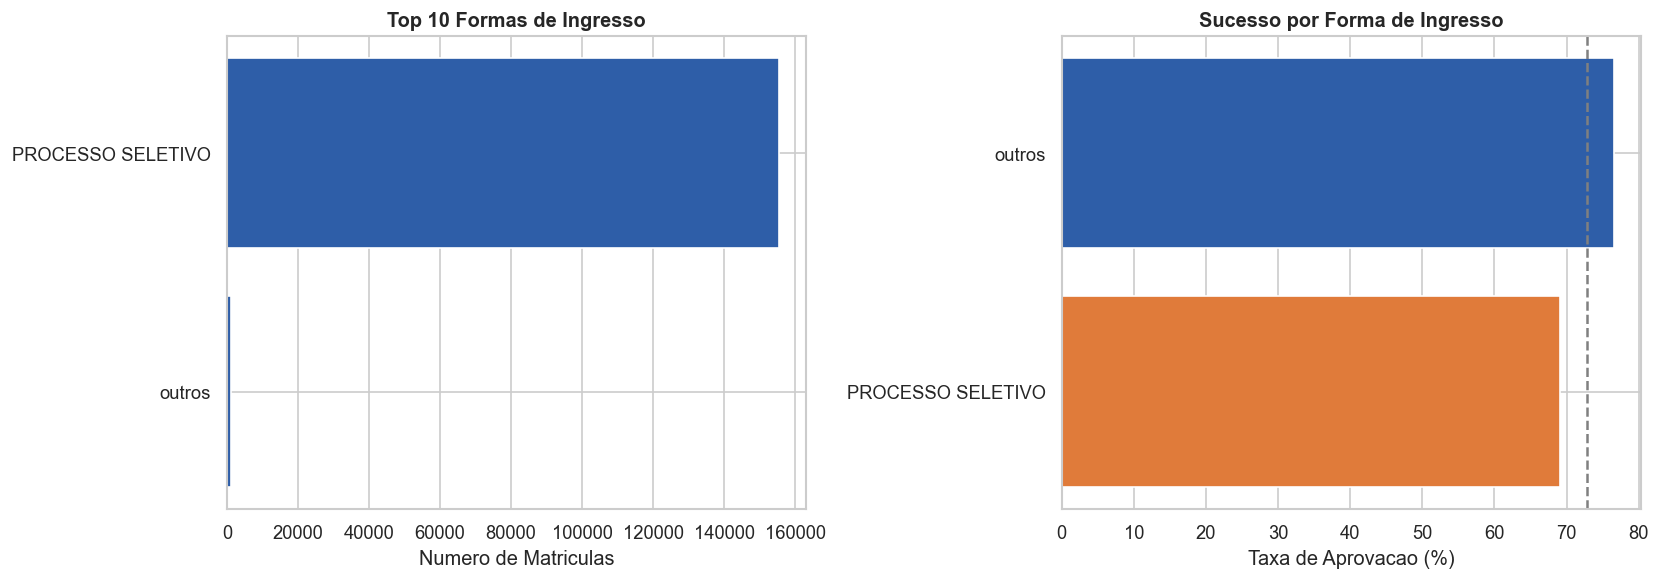

In [53]:
if 'forma_ingresso' in df_modelo.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    forma_counts = df_modelo['forma_ingresso'].value_counts().head(10)
    axes[0].barh(forma_counts.index[::-1], forma_counts.values[::-1], color='#2E5EA8')
    axes[0].set_xlabel('Numero de Matriculas')
    axes[0].set_title('Top 10 Formas de Ingresso', fontweight='bold')
    taxa_ing = df_modelo.groupby('forma_ingresso')['target'].mean().sort_values().tail(10) * 100
    colors = ['#2E5EA8' if v >= taxa_ing.mean() else '#E07B3A' for v in taxa_ing.values]
    axes[1].barh(taxa_ing.index, taxa_ing.values, color=colors)
    axes[1].axvline(taxa_ing.mean(), color='gray', linestyle='--')
    axes[1].set_xlabel('Taxa de Aprovacao (%)')
    axes[1].set_title('Sucesso por Forma de Ingresso', fontweight='bold')
    plt.tight_layout()
    plt.savefig('img/fig2_forma_ingresso.png', dpi=150, bbox_inches='tight')
    plt.show()

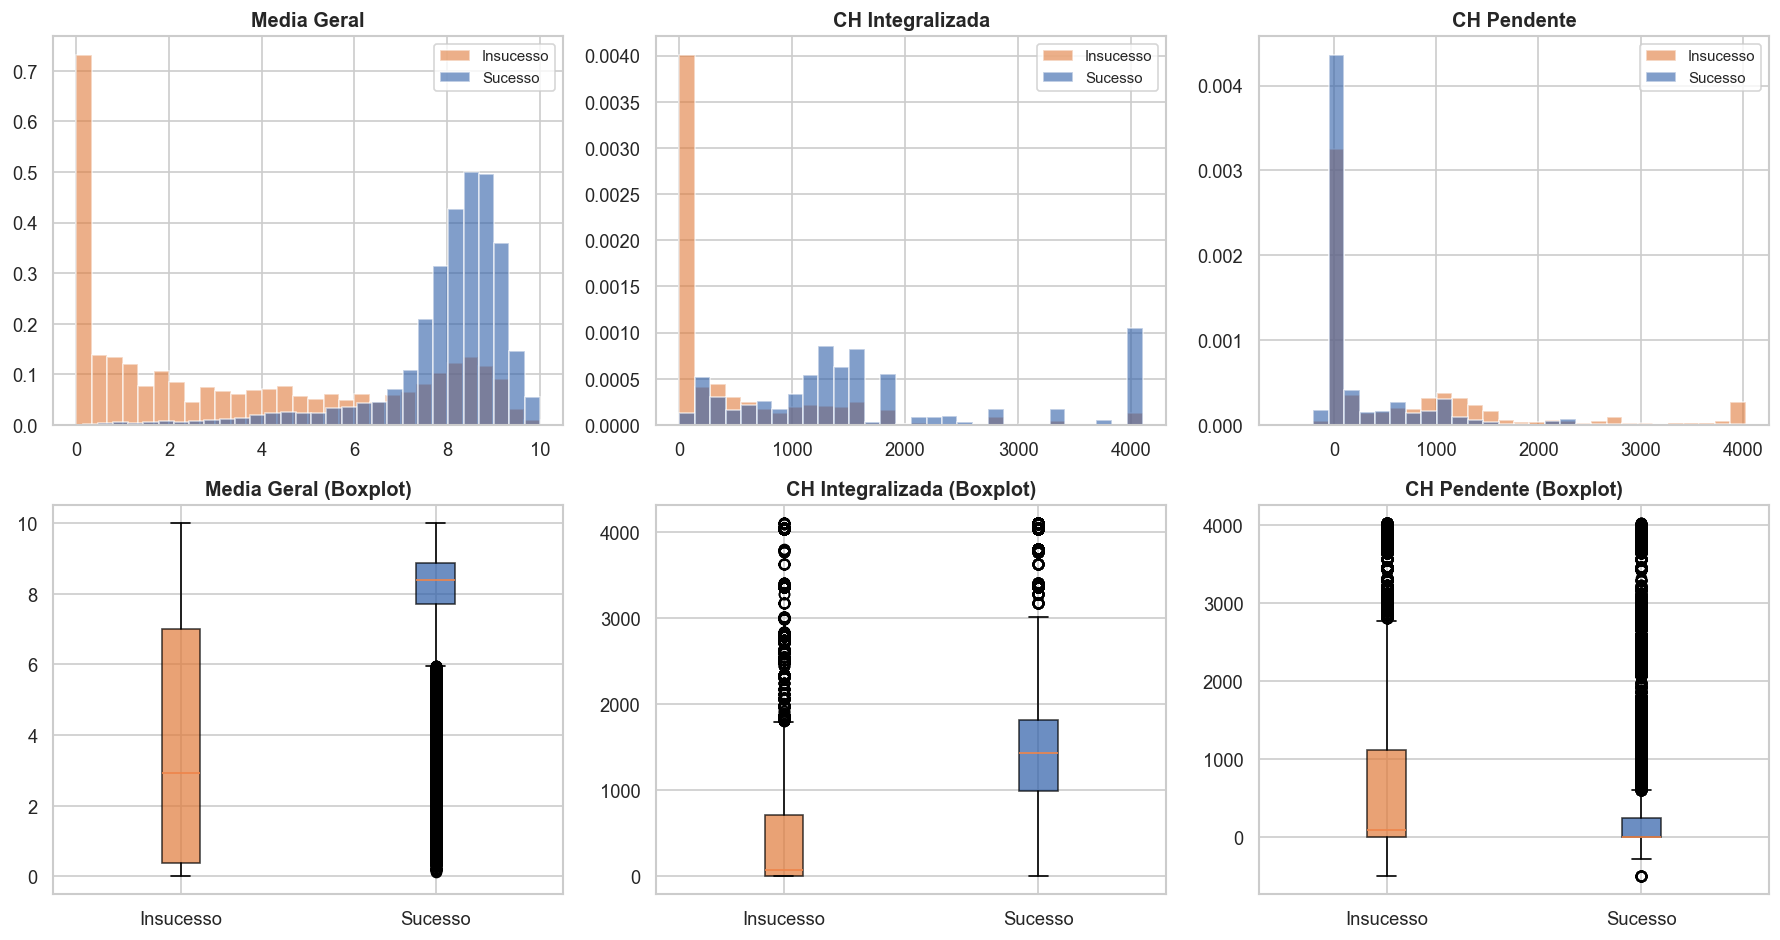

In [54]:
num_aluno = [(c, l) for c, l in [
    ('media_geral','Media Geral'),('ch_integralizada','CH Integralizada'),
    ('ch_pendente','CH Pendente'),('quantidade_membros_familia','Membros Familia')
] if c in df_modelo.columns]

if num_aluno:
    cols_p, labs_p = zip(*num_aluno)
    n = len(cols_p)
    fig, axes = plt.subplots(2, n, figsize=(5*n, 8))
    if n == 1: axes = axes.reshape(2,1)
    for i, (col, label) in enumerate(zip(cols_p, labs_p)):
        for cls, color, lbl in [(0,'#E07B3A','Insucesso'),(1,'#2E5EA8','Sucesso')]:
            subset = df_modelo[df_modelo['target']==cls][col].dropna()
            axes[0,i].hist(subset, bins=30, alpha=0.6, color=color, label=lbl, density=True)
        axes[0,i].set_title(label, fontweight='bold'); axes[0,i].legend(fontsize=9)
        data = [df_modelo[df_modelo['target']==cls][col].dropna() for cls in [0,1]]
        bp = axes[1,i].boxplot(data, patch_artist=True, labels=['Insucesso','Sucesso'])
        for patch, color in zip(bp['boxes'], ['#E07B3A','#2E5EA8']):
            patch.set_facecolor(color); patch.set_alpha(0.7)
        axes[1,i].set_title(f'{label} (Boxplot)', fontweight='bold')
    plt.tight_layout()
    plt.savefig('img/fig3_distribuicoes_numericas.png', dpi=150, bbox_inches='tight')
    plt.show()

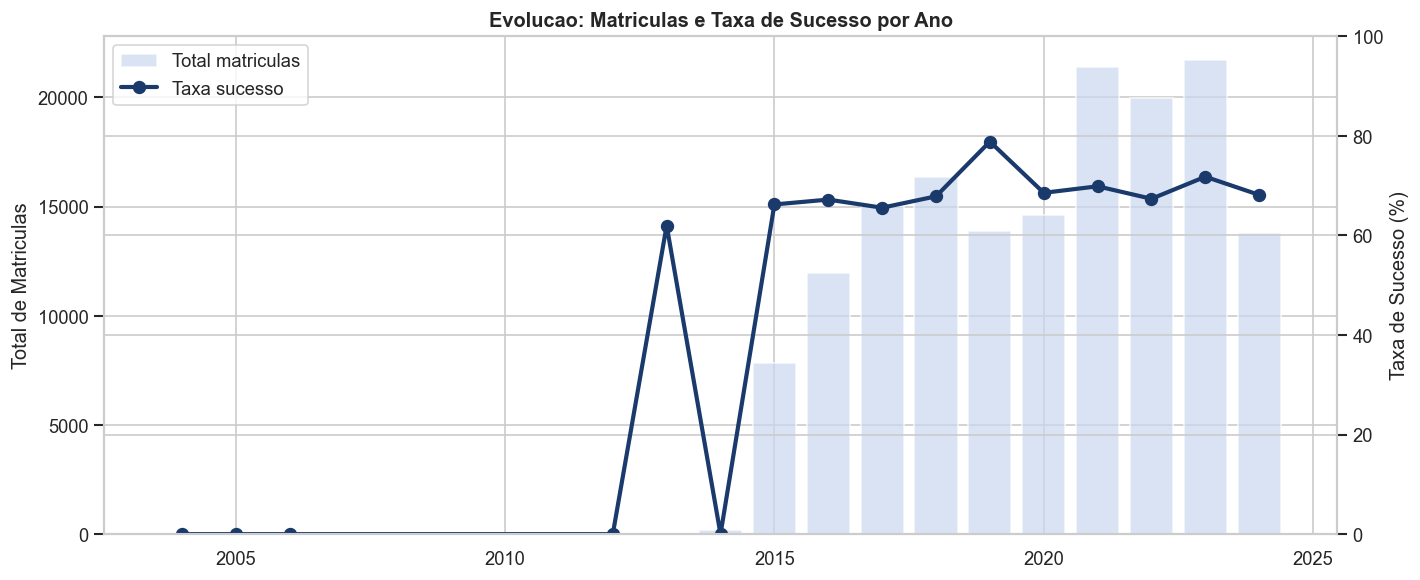

In [55]:
if 'ano' in df_modelo.columns:
    taxa_ano = df_modelo.groupby('ano')['target'].agg(['mean','count']).reset_index()
    taxa_ano.columns = ['ano','taxa_sucesso','total']
    taxa_ano['taxa_sucesso'] *= 100
    fig, ax1 = plt.subplots(figsize=(12, 5))
    ax2 = ax1.twinx()
    ax1.bar(taxa_ano['ano'], taxa_ano['total'], color='#CBD8EF', alpha=0.7, label='Total matriculas')
    ax2.plot(taxa_ano['ano'], taxa_ano['taxa_sucesso'], 'o-', color='#1A3A6B', lw=2.5, ms=7, label='Taxa sucesso')
    ax1.set_ylabel('Total de Matriculas'); ax2.set_ylabel('Taxa de Sucesso (%)'); ax2.set_ylim(0,100)
    l1, la1 = ax1.get_legend_handles_labels(); l2, la2 = ax2.get_legend_handles_labels()
    ax1.legend(l1+l2, la1+la2, loc='upper left')
    plt.title('Evolucao: Matriculas e Taxa de Sucesso por Ano', fontweight='bold')
    plt.tight_layout()
    plt.savefig('img/fig4_evolucao_temporal.png', dpi=150, bbox_inches='tight')
    plt.show()

### 5.2 Dimensão Currículo

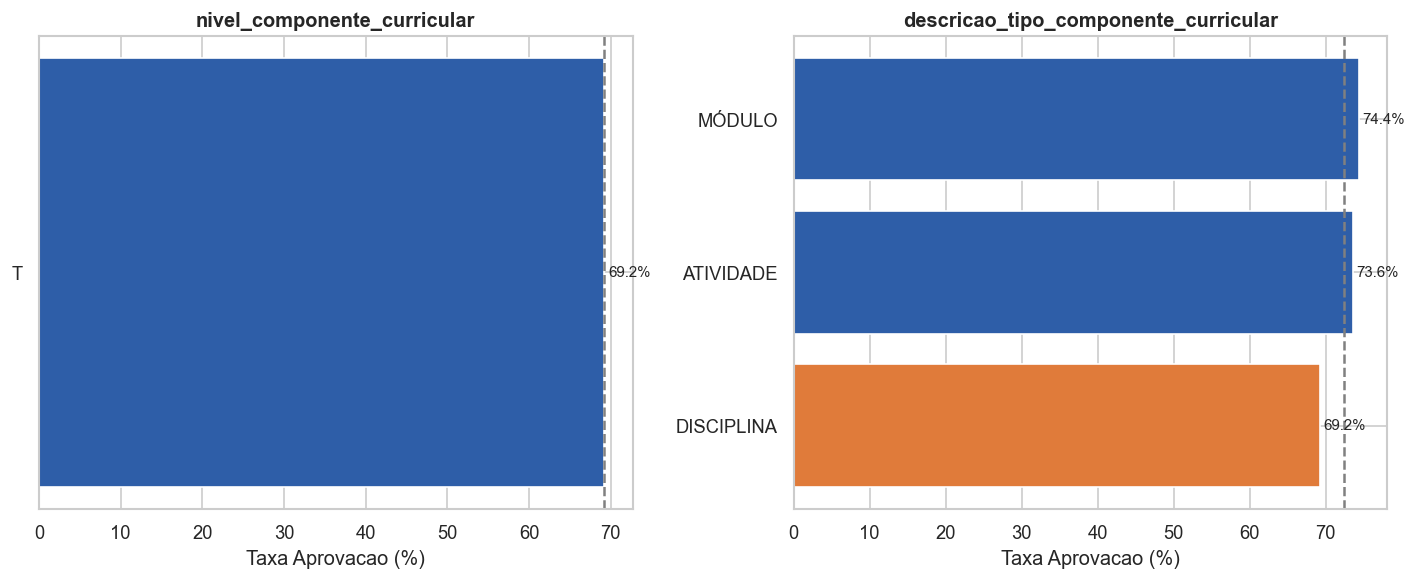

In [56]:
cols_curr = [c for c in ['nivel_componente_curricular','descricao_tipo_componente_curricular'] if c in df_modelo.columns]
if cols_curr:
    fig, axes = plt.subplots(1, len(cols_curr), figsize=(6*len(cols_curr), 5))
    if len(cols_curr) == 1: axes = [axes]
    for ax, col in zip(axes, cols_curr):
        taxa = df_modelo.groupby(col)['target'].mean().sort_values() * 100
        taxa = taxa.head(12)
        colors = ['#2E5EA8' if v >= taxa.mean() else '#E07B3A' for v in taxa.values]
        bars = ax.barh(taxa.index.astype(str), taxa.values, color=colors)
        ax.axvline(taxa.mean(), color='gray', linestyle='--')
        ax.set_xlabel('Taxa Aprovacao (%)'); ax.set_title(col, fontweight='bold')
        for bar, val in zip(bars, taxa.values):
            ax.text(val+0.5, bar.get_y()+bar.get_height()/2, f'{val:.1f}%', va='center', fontsize=9)
    plt.tight_layout()
    plt.savefig('img/fig5_taxa_sucesso_curriculo.png', dpi=150, bbox_inches='tight')
    plt.show()

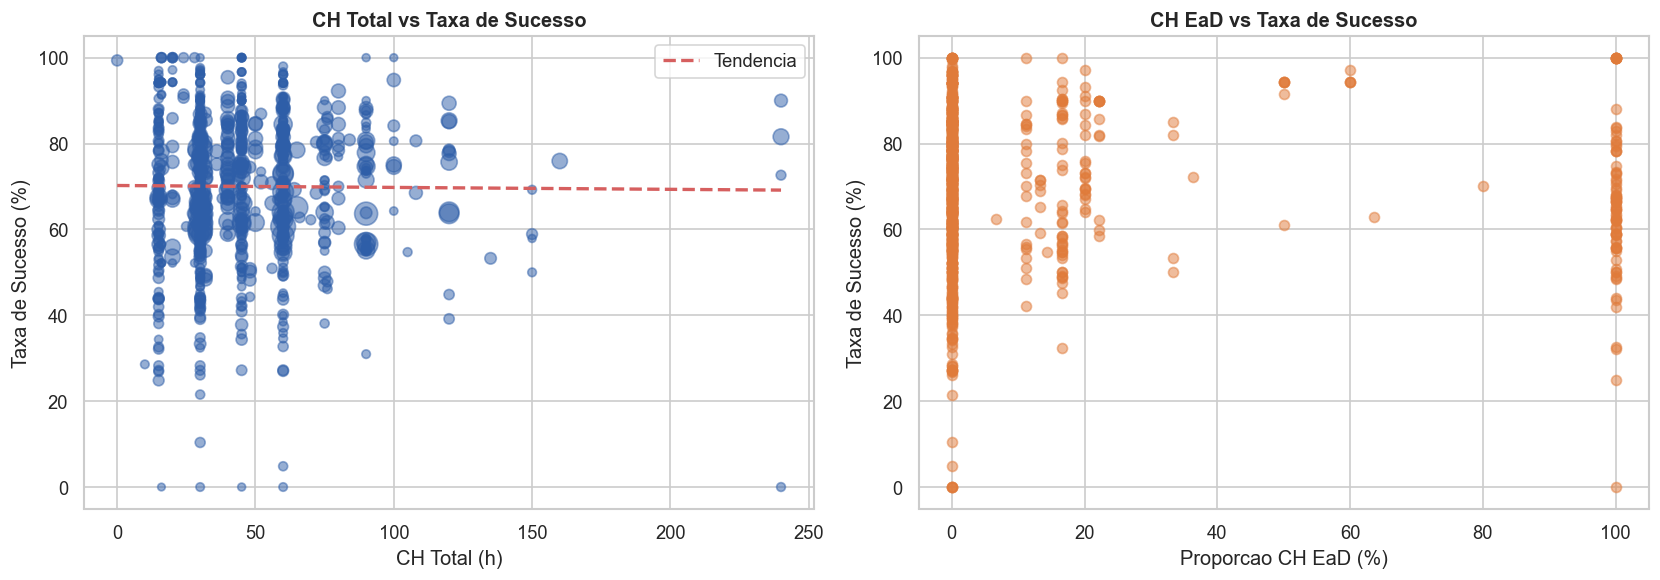

In [57]:
if {'id_disciplina','ch_total','ch_ead'}.issubset(df_modelo.columns):
    comp_taxa = df_modelo.groupby('id_disciplina').agg(
        taxa_sucesso=('target','mean'), ch_total=('ch_total','first'),
        ch_ead=('ch_ead','first'), total=('target','count')
    ).reset_index()
    comp_taxa = comp_taxa[comp_taxa['total'] >= 5]
    comp_taxa['prop_ead'] = comp_taxa['ch_ead'] / (comp_taxa['ch_total'] + 1e-6)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].scatter(comp_taxa['ch_total'], comp_taxa['taxa_sucesso']*100, alpha=0.5,
                    s=comp_taxa['total']/comp_taxa['total'].max()*200+20, color='#2E5EA8')
    valid = comp_taxa[['ch_total','taxa_sucesso']].dropna()
    if len(valid) > 1:
        p = np.poly1d(np.polyfit(valid['ch_total'], valid['taxa_sucesso']*100, 1))
        xl = np.linspace(valid['ch_total'].min(), valid['ch_total'].max(), 100)
        axes[0].plot(xl, p(xl), 'r--', lw=2, label='Tendencia')
    axes[0].set_xlabel('CH Total (h)'); axes[0].set_ylabel('Taxa de Sucesso (%)')
    axes[0].set_title('CH Total vs Taxa de Sucesso', fontweight='bold'); axes[0].legend()

    axes[1].scatter(comp_taxa['prop_ead']*100, comp_taxa['taxa_sucesso']*100, alpha=0.5, color='#E07B3A')
    axes[1].set_xlabel('Proporcao CH EaD (%)'); axes[1].set_ylabel('Taxa de Sucesso (%)')
    axes[1].set_title('CH EaD vs Taxa de Sucesso', fontweight='bold')
    plt.tight_layout()
    plt.savefig('img/fig6_ch_vs_taxa.png', dpi=150, bbox_inches='tight')
    plt.show()

### 5.3 Dimensão Professor

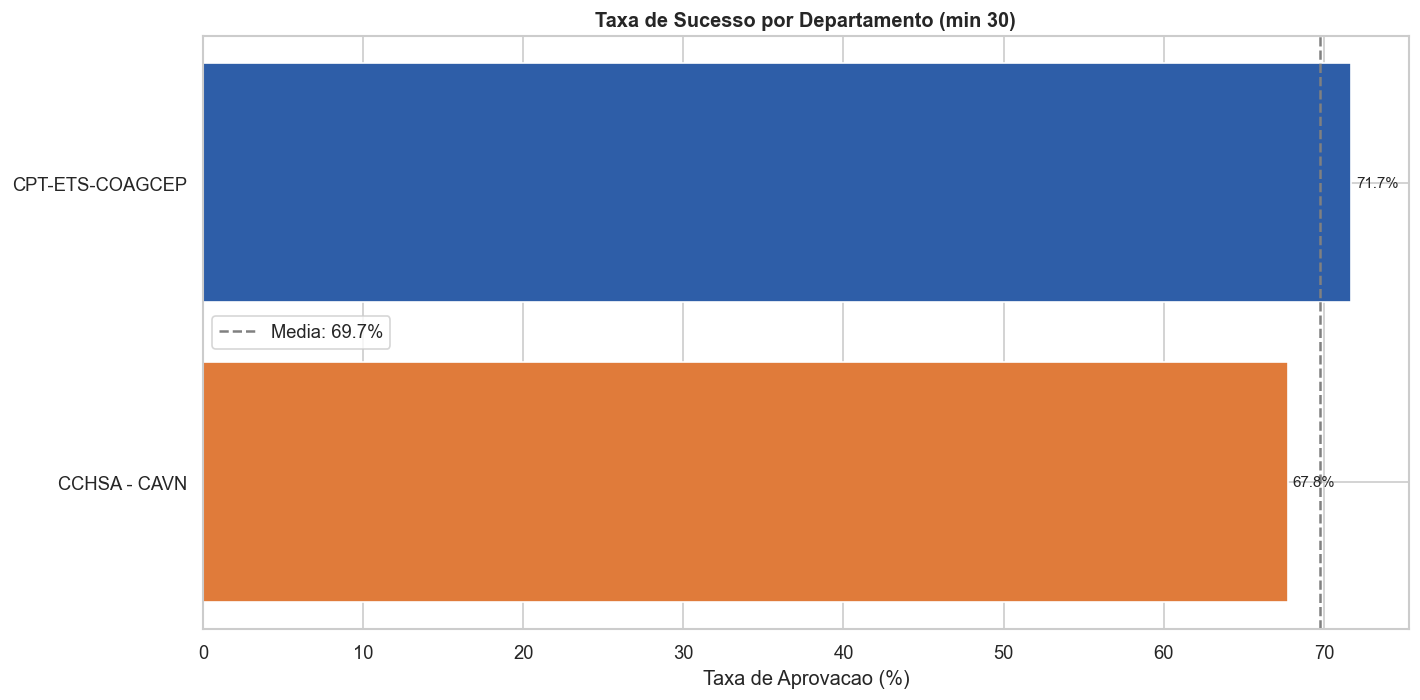

In [58]:
if 'sigla_departamento' in df_modelo.columns:
    taxa_dept = df_modelo.groupby('sigla_departamento').agg(
        taxa_sucesso=('target','mean'), total=('target','count')
    ).reset_index()
    taxa_dept = taxa_dept[taxa_dept['total'] >= 30].sort_values('taxa_sucesso')
    taxa_dept['taxa_sucesso'] *= 100
    fig, ax = plt.subplots(figsize=(12, max(6, len(taxa_dept)*0.4)))
    colors = ['#2E5EA8' if v >= taxa_dept['taxa_sucesso'].mean() else '#E07B3A' for v in taxa_dept['taxa_sucesso']]
    bars = ax.barh(taxa_dept['sigla_departamento'], taxa_dept['taxa_sucesso'], color=colors)
    ax.axvline(taxa_dept['taxa_sucesso'].mean(), color='gray', linestyle='--', lw=1.5,
               label=f'Media: {taxa_dept["taxa_sucesso"].mean():.1f}%')
    ax.set_xlabel('Taxa de Aprovacao (%)'); ax.set_title('Taxa de Sucesso por Departamento (min 30)', fontweight='bold')
    ax.legend()
    for bar, val in zip(bars, taxa_dept['taxa_sucesso']):
        ax.text(val+0.3, bar.get_y()+bar.get_height()/2, f'{val:.1f}%', va='center', fontsize=9)
    plt.tight_layout()
    plt.savefig('img/fig7_taxa_departamento.png', dpi=150, bbox_inches='tight')
    plt.show()

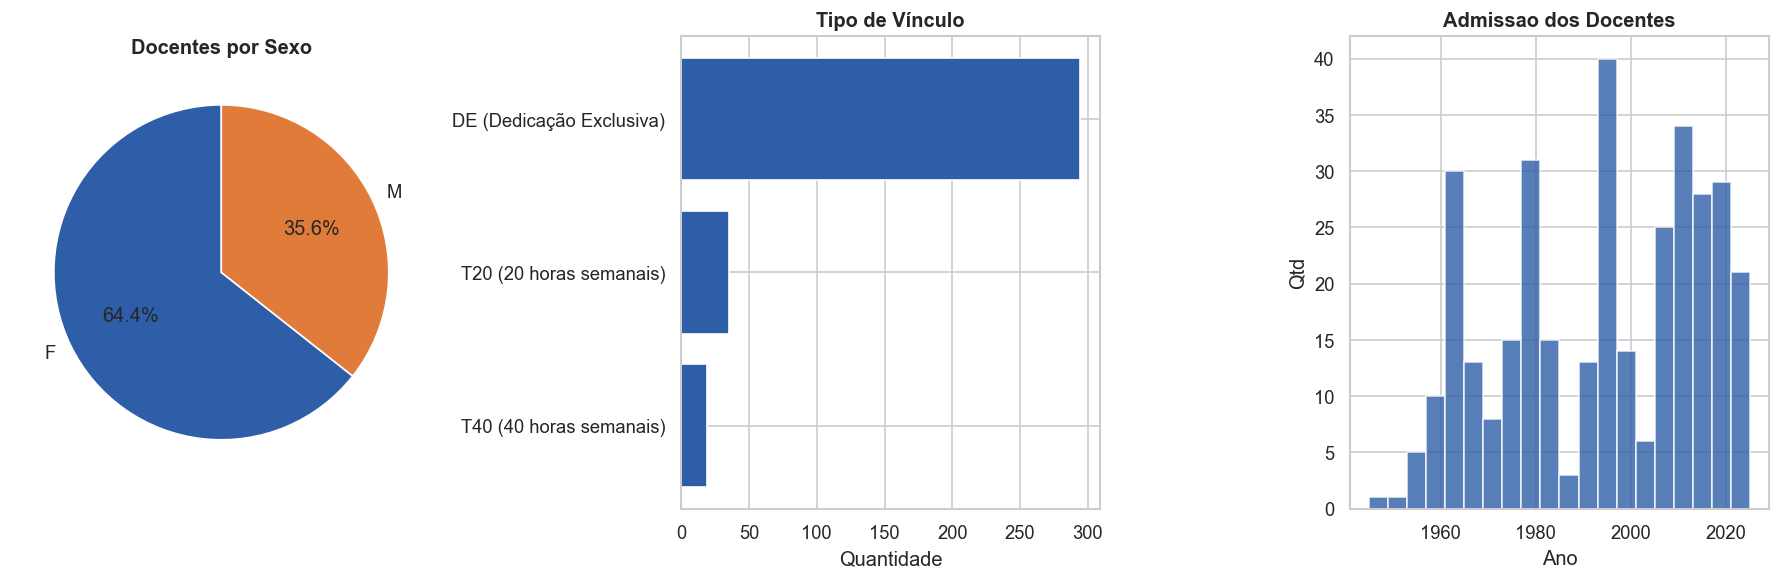

Total docentes: 348


In [59]:
cols_doc = [c for c in ['sexo','tipo_vinculo','ano_admissao'] if c in docentes.columns]
if cols_doc:
    fig, axes = plt.subplots(1, len(cols_doc), figsize=(5*len(cols_doc), 5))
    if len(cols_doc) == 1: axes = [axes]
    for i, col in enumerate(cols_doc):
        ax = axes[i]
        if col == 'sexo':
            vc2 = docentes['sexo'].value_counts()
            ax.pie(vc2.values, labels=vc2.index, autopct='%1.1f%%', colors=['#2E5EA8','#E07B3A'], startangle=90)
            ax.set_title('Docentes por Sexo', fontweight='bold')
        elif col == 'tipo_vinculo':
            col_plot = 'tipo_vinculo_label' if 'tipo_vinculo_label' in docentes.columns else 'tipo_vinculo'
            vc2 = docentes[col_plot].value_counts().head(6)
            ax.barh(vc2.index[::-1], vc2.values[::-1], color='#2E5EA8')
            ax.set_xlabel('Quantidade'); ax.set_title('Tipo de Vínculo', fontweight='bold')
        elif col == 'ano_admissao':
            docentes['ano_admissao'].dropna().hist(bins=20, color='#2E5EA8', alpha=0.8, ax=ax)
            ax.set_xlabel('Ano'); ax.set_ylabel('Qtd'); ax.set_title('Admissao dos Docentes', fontweight='bold')
    plt.tight_layout()
    plt.savefig('img/fig8_perfil_docente.png', dpi=150, bbox_inches='tight')
    plt.show()
print(f'Total docentes: {len(docentes)}')

### 5.4 Análise da Variável-Alvo

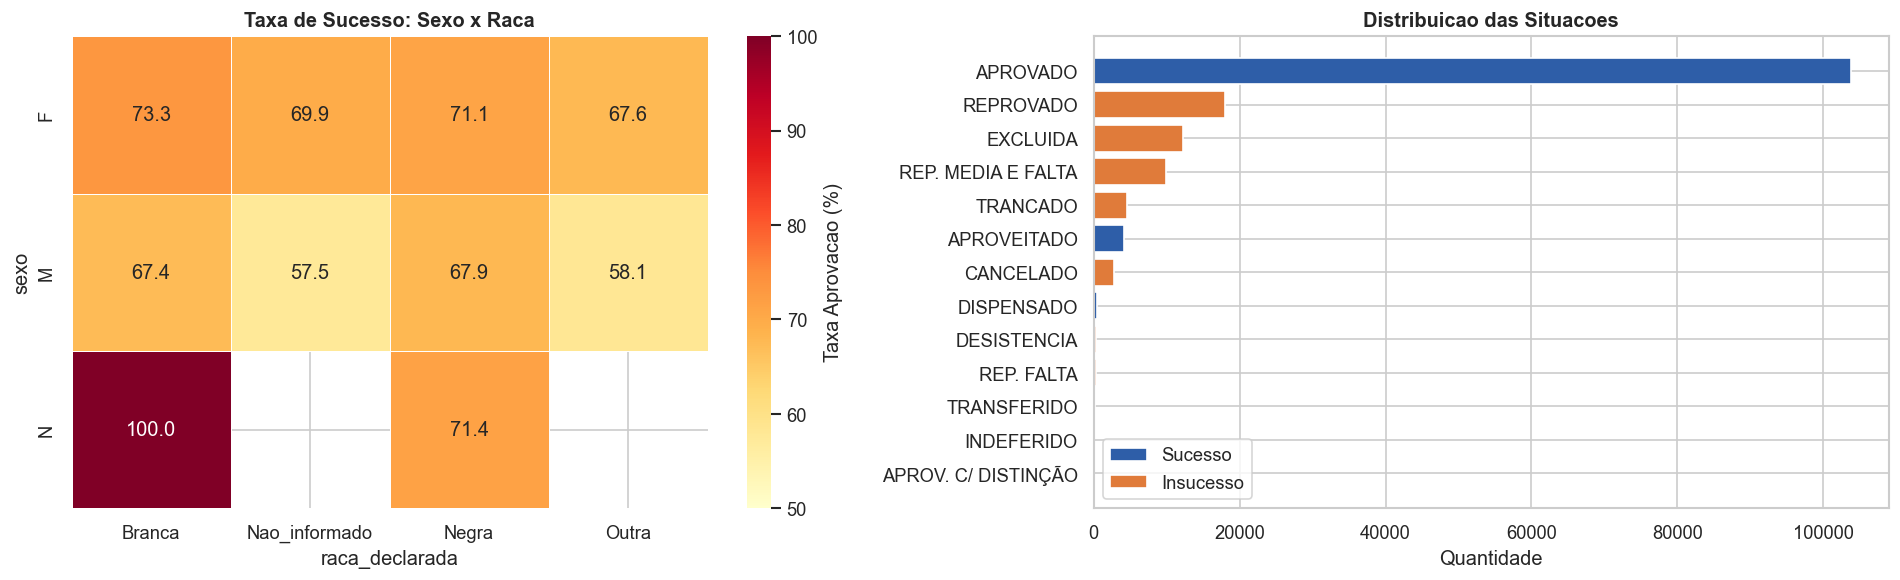

In [60]:
if {'sexo','raca_declarada'}.issubset(df_modelo.columns):
    pivot = df_modelo.groupby(['sexo','raca_declarada'])['target'].mean().unstack() * 100
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    sns.heatmap(pivot, annot=True, fmt='.1f', cmap='YlOrRd', ax=axes[0], linewidths=0.5,
                vmin=50, vmax=100, cbar_kws={'label': 'Taxa Aprovacao (%)'})
    axes[0].set_title('Taxa de Sucesso: Sexo x Raca', fontweight='bold')
    sit_counts = df_modelo['situacao'].value_counts()
    colors_map = ['#2E5EA8' if s in SITUACOES_SUCESSO else '#E07B3A' for s in sit_counts.index]
    axes[1].barh(sit_counts.index[::-1], sit_counts.values[::-1], color=colors_map[::-1])
    axes[1].set_xlabel('Quantidade')
    axes[1].set_title('Distribuicao das Situacoes', fontweight='bold')
    axes[1].legend(handles=[Patch(facecolor='#2E5EA8',label='Sucesso'),Patch(facecolor='#E07B3A',label='Insucesso')])
    plt.tight_layout()
    plt.savefig('img/fig9_analise_alvo.png', dpi=150, bbox_inches='tight')
    plt.show()

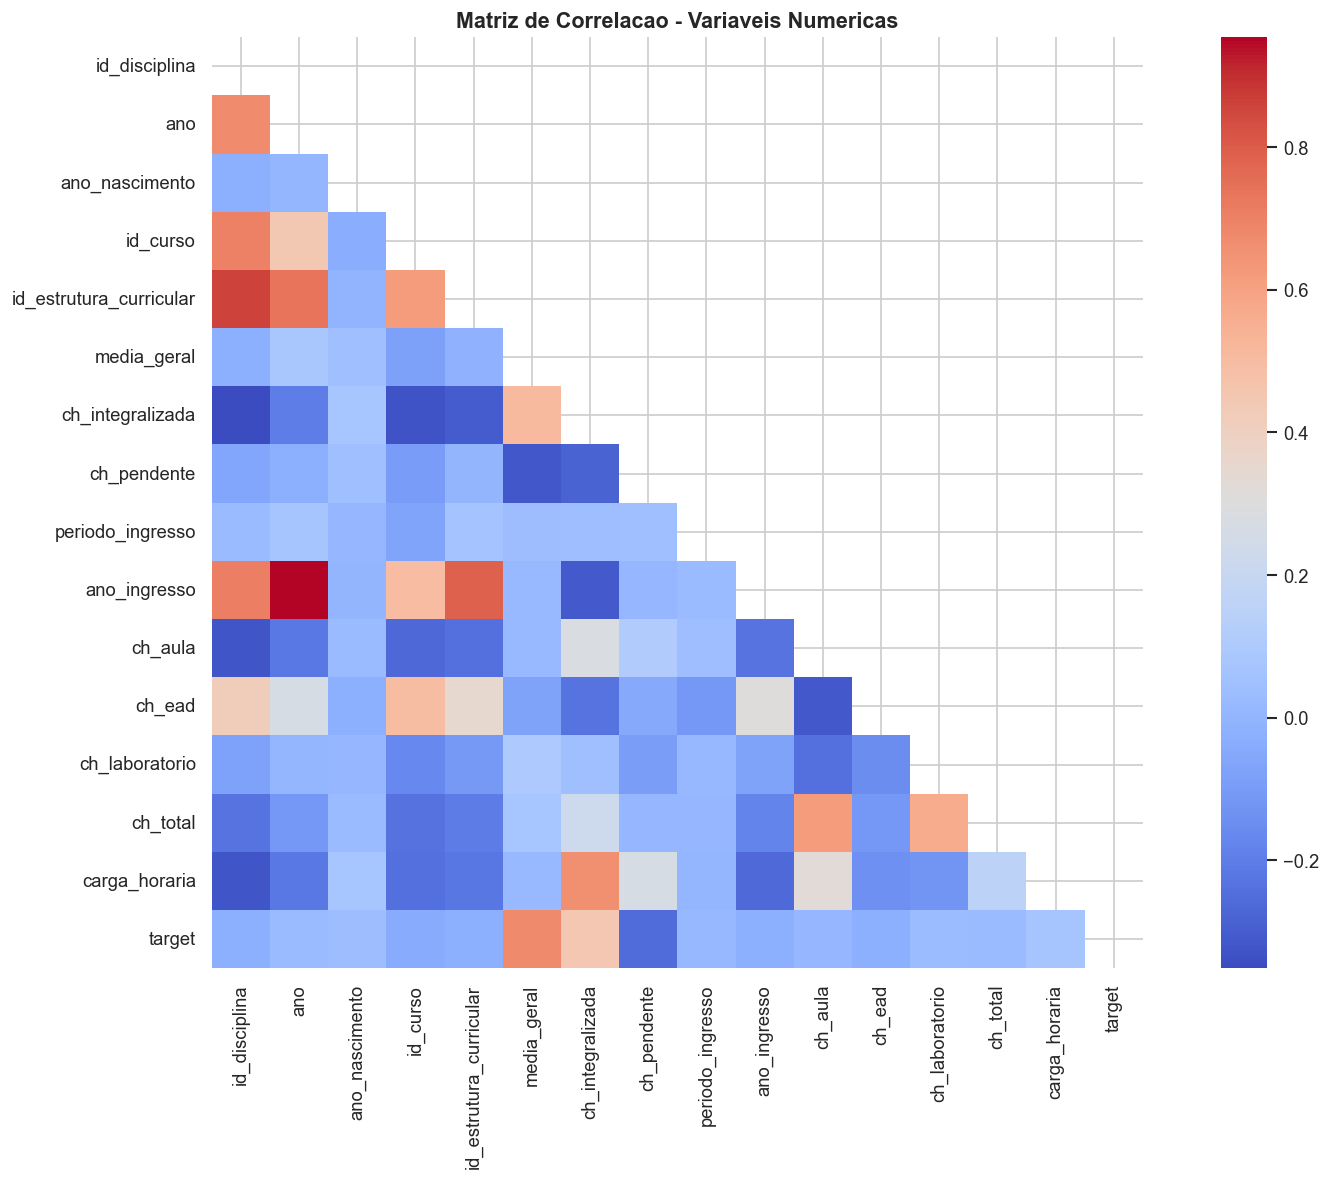

In [61]:
num_cols = df_modelo.select_dtypes(include='number').columns
corr_matrix = df_modelo[num_cols].corr()
fig, ax = plt.subplots(figsize=(14, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, fmt='.2f', cmap='coolwarm',
     square=True,
)
ax.set_title('Matriz de Correlacao - Variaveis Numericas', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('fig10_correlacao.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Pré-processamento e Feature Engineering

In [142]:
df_modelo.info()

<class 'pandas.DataFrame'>
Index: 156697 entries, 11 to 426752
Data columns (total 32 columns):
 #   Column                                Non-Null Count   Dtype   
---  ------                                --------------   -----   
 0   id_discente                           156697 non-null  object  
 1   id_disciplina                         156697 non-null  int64   
 2   ano                                   156697 non-null  int64   
 3   periodo                               156697 non-null  object  
 4   situacao                              156697 non-null  object  
 5   sexo                                  156697 non-null  object  
 6   ano_nascimento                        156652 non-null  float64 
 7   estado_civil                          156697 non-null  object  
 8   raca_declarada                        156697 non-null  object  
 9   id_curso                              156697 non-null  float64 
 10  id_estrutura_curricular               156697 non-null  float64 
 11  me

In [147]:
SUCESSO = {
    "APROVADO",
    "APROVEITADO",
    "DISPENSADO",
    "APROV. C/ DISTINÇÃO",
}
REPROVA = {
    "REPROVADO",
    "REP. MEDIA E FALTA",
    "REP. FALTA",
}

df = df_modelo.copy()
df["_po"] = pd.to_numeric(
    df["periodo"].astype(str).str.extract(r"(\d+)")[0], errors="coerce"
)
df = df.sort_values(
    ["id_discente", "ano", "_po", "id_disciplina"],
    kind="mergesort",
)
df = df.copy()
df["_po"] = pd.to_numeric(
    df["periodo"].astype(str).str.extract(r"(\d+)")[0], errors="coerce"
)
df = df.sort_values(
    ["id_discente", "ano", "_po", "id_disciplina"],
    kind="mergesort",
)

def _blank():
    return {"n_ok": 0, "n_rep": 0, "ch_ok": 0.0, "ch_rep": 0.0}
n_ok_l, n_rep_l = [], []
ch_ok_l, ch_rep_l = [], []
taxa_n_l, taxa_ch_l = [], []
for _, g in df.groupby("id_discente", sort=False):
    por_area = {}
    for _, row in g.iterrows():
        area = row["area_conhecimento"]
        if pd.isna(area) or str(area).strip() == "":
            area = "__sem_area__"
        st = por_area.get(area, _blank())
        # --- tudo que vem DAQUI PRA BAIXO é "antes" desta matrícula, só desta área ---
        n_ok, n_rep = st["n_ok"], st["n_rep"]
        ch_ok, ch_rep = st["ch_ok"], st["ch_rep"]
        n_ok_l.append(n_ok)
        n_rep_l.append(n_rep)
        ch_ok_l.append(ch_ok)
        ch_rep_l.append(ch_rep)
        den_n = n_ok + n_rep
        taxa_n_l.append(n_ok / den_n if den_n else np.nan)
        den_ch = ch_ok + ch_rep
        taxa_ch_l.append(ch_ok / den_ch if den_ch > 0 else np.nan)
        # --- agora incorpora ESTA linha no histórico (próximas linhas "veem" isso) ---
        sit = row["situacao"]
        ch = float(row["ch_total"]) if pd.notna(row["ch_total"]) else 0.0
        if sit in SUCESSO:
            st["n_ok"] += 1
            st["ch_ok"] += ch
        elif sit in REPROVA:
            st["n_rep"] += 1
            st["ch_rep"] += ch
        por_area[area] = st
df["n_aprov_antes_mesma_area"] = n_ok_l
df["n_reprov_antes_mesma_area"] = n_rep_l
df["ch_aprov_antes_mesma_area"] = ch_ok_l
df["ch_reprov_antes_mesma_area"] = ch_rep_l
df["taxa_sucesso_count_antes_mesma_area"] = taxa_n_l  # aprovações / (aprov + reprov)
df["taxa_sucesso_ch_antes_mesma_area"] = taxa_ch_l    # CH aprov / (CH aprov + CH reprov)
df = df.drop(columns=["_po"], errors="ignore")

In [148]:
df_modelo_tratado = df

In [149]:
def make_dummie(df, col):
    """
    Substitui `col` por colunas dummie: binária (1 coluna) ou one-hot (get_dummies).
    Retorna cópia do dataframe com `col` removida e prefixo dummie_{col}.
    """
    out = df.copy()
    if col not in out.columns:
        return out
    unique_vals = out[col].dropna().unique()
    if len(unique_vals) == 2:
        first_val = unique_vals[0]
        new_col = f'dummie_{col}'
        out[new_col] = (out[col] == first_val).astype(float)
        return out.drop(columns=[col])
    if len(unique_vals) == 0:
        return out.drop(columns=[col])
    dummies = pd.get_dummies(out[col], prefix=f'dummie_{col}').astype(float)
    return pd.concat([out.drop(columns=[col]), dummies], axis=1)


    
colunas = ['sexo', 'curso_nome' ,'estado_civil','sigla_centro' ,'raca_declarada', 'faixa_renda_familiar', 'forma_ingresso', 'faixa_membros_familia', 'area_conhecimento']
df_tratado = df_modelo_tratado.copy()
for col in colunas:
    if col in df_tratado.columns:
        df_tratado = make_dummie(df_tratado, col)

df_modelo_tratado = df_tratado


In [150]:
df_modelo_tratado.info()

<class 'pandas.DataFrame'>
Index: 156697 entries, 254385 to 164087
Data columns (total 80 columns):
 #   Column                                                                                                             Non-Null Count   Dtype  
---  ------                                                                                                             --------------   -----  
 0   id_discente                                                                                                        156697 non-null  object 
 1   id_disciplina                                                                                                      156697 non-null  int64  
 2   ano                                                                                                                156697 non-null  int64  
 3   periodo                                                                                                            156697 non-null  object 
 4   situacao                 

In [151]:


df_modelo_tratado["primeiro_periodo"] = (df_modelo_tratado["ano"].astype(float) == df_modelo_tratado["ano_ingresso"].astype(float)).astype(np.int8)

In [152]:

df_modelo_tratado.info()

<class 'pandas.DataFrame'>
Index: 156697 entries, 254385 to 164087
Data columns (total 81 columns):
 #   Column                                                                                                             Non-Null Count   Dtype  
---  ------                                                                                                             --------------   -----  
 0   id_discente                                                                                                        156697 non-null  object 
 1   id_disciplina                                                                                                      156697 non-null  int64  
 2   ano                                                                                                                156697 non-null  int64  
 3   periodo                                                                                                            156697 non-null  object 
 4   situacao                 

In [153]:
df_modelo_tratado['idade'] = df_modelo_tratado['ano'] - df_modelo_tratado['ano_nascimento']



k = 1.5
colunas = ["idade"]

for col in colunas:
    if col not in df_modelo_tratado.columns:
        continue
    mask = mascara_outliers_iqr(df_modelo_tratado[col], k=k, apenas_superior=False)
    # alinhar ao índice do dataframe (dropna remove índices no cálculo)
    mask = mask.reindex(df_modelo_tratado.index).fillna(False)
    df_modelo_tratado.loc[mask, col] = np.nan

# depois: imputar média como você combinou
for col in colunas:
    if col in df_modelo_tratado.columns:
        df_modelo_tratado[col] = df_modelo_tratado[col].fillna(df_modelo_tratado[col].median())

In [157]:
df_modelo_tratado.info()

<class 'pandas.DataFrame'>
Index: 156697 entries, 254385 to 164087
Data columns (total 82 columns):
 #   Column                                                                                                             Non-Null Count   Dtype  
---  ------                                                                                                             --------------   -----  
 0   id_discente                                                                                                        156697 non-null  object 
 1   id_disciplina                                                                                                      156697 non-null  int64  
 2   ano                                                                                                                156697 non-null  int64  
 3   periodo                                                                                                            156697 non-null  object 
 4   situacao                 

In [158]:

dummies = [x for x in df_modelo_tratado if "dummie" in x ]
FEATURES_ALUNO = [
    #'media_geral',
    'idade',
    'ano_ingresso',
    'periodo_ingresso',
    'uf_titulo_eleitor_pb',
    'uf_naturalidade_pb'
]

FEATURES_CURRICULO = [
    'ch_aula',
    'ch_laboratorio',
    'ch_ead',
    "n_aprov_antes_mesma_area" ,  
    "n_reprov_antes_mesma_area" ,
    "ch_aprov_antes_mesma_area" ,
    "ch_reprov_antes_mesma_area" ,
    "taxa_sucesso_count_antes_mesma_area" ,
    "taxa_sucesso_ch_antes_mesma_area"
]

FEATURES_PROFESSOR = [
    'total_docentes',
    'ano_admissao_medio',
    'prop_feminino',
    'prop_de',
    'prop_t40',
    'prop_t20',
]

ALL_FEATURES = [
    f for f in FEATURES_ALUNO + FEATURES_CURRICULO + FEATURES_PROFESSOR
    if f in df_modelo_tratado.columns
]

# Sem ch_total no df: denominador = soma das CH do componente
if {'ch_ead', 'ch_aula', 'ch_laboratorio'}.issubset(df_modelo_tratado.columns):
    ch_sum = df_modelo_tratado['ch_aula'] + df_modelo_tratado['ch_laboratorio'] + df_modelo['ch_ead']

ALL_FEATURES = list(dict.fromkeys(ALL_FEATURES)) + dummies

In [159]:
ALL_FEATURES

['idade',
 'ano_ingresso',
 'periodo_ingresso',
 'ch_aula',
 'ch_laboratorio',
 'ch_ead',
 'n_aprov_antes_mesma_area',
 'n_reprov_antes_mesma_area',
 'ch_aprov_antes_mesma_area',
 'ch_reprov_antes_mesma_area',
 'taxa_sucesso_count_antes_mesma_area',
 'taxa_sucesso_ch_antes_mesma_area',
 'dummie_sexo_F',
 'dummie_sexo_M',
 'dummie_sexo_N',
 'dummie_curso_nome_Formação Inicial e Continuada:Língua Portuguesa e Cultura Brasileira para Estrangeiros - Básico',
 'dummie_curso_nome_TÉCNICO DE NÍVEL MÉDIO EM AGROINDÚSTRIA NA FORMA INTEGRADA',
 'dummie_curso_nome_TÉCNICO DE NÍVEL MÉDIO EM AGROINDÚSTRIA NA FORMA SUBSEQUENTE',
 'dummie_curso_nome_TÉCNICO DE NÍVEL MÉDIO EM AGROPECUÁRIA - INTEGRADO - PROEJA',
 'dummie_curso_nome_TÉCNICO DE NÍVEL MÉDIO EM AGROPECUÁRIA NA FORMA INTEGRADA',
 'dummie_curso_nome_TÉCNICO DE NÍVEL MÉDIO EM AGROPECUÁRIA NA FORMA SUBSEQUENTE',
 'dummie_curso_nome_TÉCNICO DE NÍVEL MÉDIO EM AQUICULTURA NA FORMA SUBSEQUENTE',
 'dummie_curso_nome_TÉCNICO DE NÍVEL MÉDIO EM GUIA D

In [160]:
X = df_modelo_tratado[ALL_FEATURES].copy()
y = df_modelo_tratado['target'].copy()

FEAT_NUM = X.select_dtypes(include=['number']).columns.tolist()
FEAT_CAT = X.select_dtypes(include=['object','category']).columns.tolist()

num_pipeline = Pipeline([('imputer', SimpleImputer(strategy='median')),
                          ('scaler', StandardScaler())])
cat_pipeline = Pipeline([('imputer', SimpleImputer(strategy='most_frequent')),
                          ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))])

transformers = [('num', num_pipeline, FEAT_NUM)]
if FEAT_CAT:
    transformers.append(('cat', cat_pipeline, FEAT_CAT))
preprocessor = ColumnTransformer(transformers)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

print(f'Treino: {X_train.shape[0]:,} | Teste: {X_test.shape[0]:,}')
print(f'Numericas ({len(FEAT_NUM)}): {FEAT_NUM}')
print(f'Categoricas ({len(FEAT_CAT)}): {FEAT_CAT}')
print(f'Nulos em X: {X.isnull().sum().sum()}')

Treino: 125,357 | Teste: 31,340
Numericas (63): ['idade', 'ano_ingresso', 'periodo_ingresso', 'ch_aula', 'ch_laboratorio', 'ch_ead', 'n_aprov_antes_mesma_area', 'n_reprov_antes_mesma_area', 'ch_aprov_antes_mesma_area', 'ch_reprov_antes_mesma_area', 'taxa_sucesso_count_antes_mesma_area', 'taxa_sucesso_ch_antes_mesma_area', 'dummie_sexo_F', 'dummie_sexo_M', 'dummie_sexo_N', 'dummie_curso_nome_Formação Inicial e Continuada:Língua Portuguesa e Cultura Brasileira para Estrangeiros - Básico', 'dummie_curso_nome_TÉCNICO DE NÍVEL MÉDIO EM AGROINDÚSTRIA NA FORMA INTEGRADA', 'dummie_curso_nome_TÉCNICO DE NÍVEL MÉDIO EM AGROINDÚSTRIA NA FORMA SUBSEQUENTE', 'dummie_curso_nome_TÉCNICO DE NÍVEL MÉDIO EM AGROPECUÁRIA - INTEGRADO - PROEJA', 'dummie_curso_nome_TÉCNICO DE NÍVEL MÉDIO EM AGROPECUÁRIA NA FORMA INTEGRADA', 'dummie_curso_nome_TÉCNICO DE NÍVEL MÉDIO EM AGROPECUÁRIA NA FORMA SUBSEQUENTE', 'dummie_curso_nome_TÉCNICO DE NÍVEL MÉDIO EM AQUICULTURA NA FORMA SUBSEQUENTE', 'dummie_curso_nome_TÉCNIC

## 7. Modelagem Supervisionada

| Modelo | Justificativa |
|--------|---------------|
| Dummy | Baseline de referencia |
| Regressao Logistica | Linear, interpretavel |
| Arvore de Decisao | Interpretavel, nao-linear |
| Random Forest | Robusto, ensemble |
| Gradient Boosting | Alta performance |
| XGBoost | Estado da arte tabulares |

In [161]:
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_pos = neg / max(pos, 1)

modelos = {
    'Baseline (Dummy)'   : DummyClassifier(strategy='most_frequent', random_state=SEED),
    'Regressao Logistica': LogisticRegression(max_iter=1000, random_state=SEED, class_weight='balanced'),
    'Arvore de Decisao'  : DecisionTreeClassifier(max_depth=8, random_state=SEED, class_weight='balanced'),
    'Random Forest'      : RandomForestClassifier(n_estimators=200, random_state=SEED, class_weight='balanced', n_jobs=-1),
    'Gradient Boosting'  : GradientBoostingClassifier(n_estimators=200, random_state=SEED),
    'XGBoost'            : XGBClassifier(n_estimators=200, random_state=SEED, eval_metric='logloss', scale_pos_weight=scale_pos)
}

resultados = []
pipelines_treinados = {}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

for nome, modelo in modelos.items():
    pipe = Pipeline([('preprocessor', preprocessor), ('classifier', modelo)])
    pipe.fit(X_train, y_train)
    y_pred  = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:,1] if hasattr(modelo,'predict_proba') else np.zeros(len(y_test))
    cv_sc   = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='f1', n_jobs=-1)
    resultados.append({
        'Modelo'      : nome,
        'Acuracia'    : accuracy_score(y_test, y_pred),
        'Precisao'    : precision_score(y_test, y_pred, zero_division=0),
        'Recall'      : recall_score(y_test, y_pred, zero_division=0),
        'F1-Score'    : f1_score(y_test, y_pred, zero_division=0),
        'AUC-ROC'     : roc_auc_score(y_test, y_proba) if y_proba.sum() > 0 else 0.5,
        'F1-CV Medio' : cv_sc.mean(),
        'F1-CV Std'   : cv_sc.std()
    })
    pipelines_treinados[nome] = pipe
    print(f'{nome:<25} F1={f1_score(y_test,y_pred,zero_division=0):.4f}  AUC={roc_auc_score(y_test,y_proba) if y_proba.sum()>0 else 0.5:.4f}')

df_resultados = pd.DataFrame(resultados)
display(df_resultados.sort_values('F1-Score', ascending=False).style.highlight_max(
    subset=['Acuracia','Precisao','Recall','F1-Score','AUC-ROC','F1-CV Medio'], color='#b3d9a3'
))

Baseline (Dummy)          F1=0.8181  AUC=0.5000
Regressao Logistica       F1=0.8334  AUC=0.8153
Arvore de Decisao         F1=0.8507  AUC=0.8433
Random Forest             F1=0.8889  AUC=0.9024
Gradient Boosting         F1=0.8775  AUC=0.8633
XGBoost                   F1=0.8805  AUC=0.9140


,Modelo,Acuracia,Precisao,Recall,F1-Score,AUC-ROC,F1-CV Medio,F1-CV Std
3,Random Forest,0.844639,0.879872,0.898165,0.888924,0.902352,0.885380,0.000612
5,XGBoost,0.839726,0.909538,0.853310,0.880527,0.914010,0.877665,0.001119
4,Gradient Boosting,0.822814,0.841162,0.917204,0.877539,0.863280,0.875376,0.001042
2,Arvore de Decisao,0.798819,0.874434,0.828278,0.850730,0.843326,0.855610,0.001449
1,Regressao Logistica,0.773867,0.850257,0.817214,0.833408,0.815338,0.833623,0.002015
0,Baseline (Dummy),0.692151,0.692151,1.000000,0.818072,0.500000,0.818084,0.000010


## 8. Comparação dos Modelos

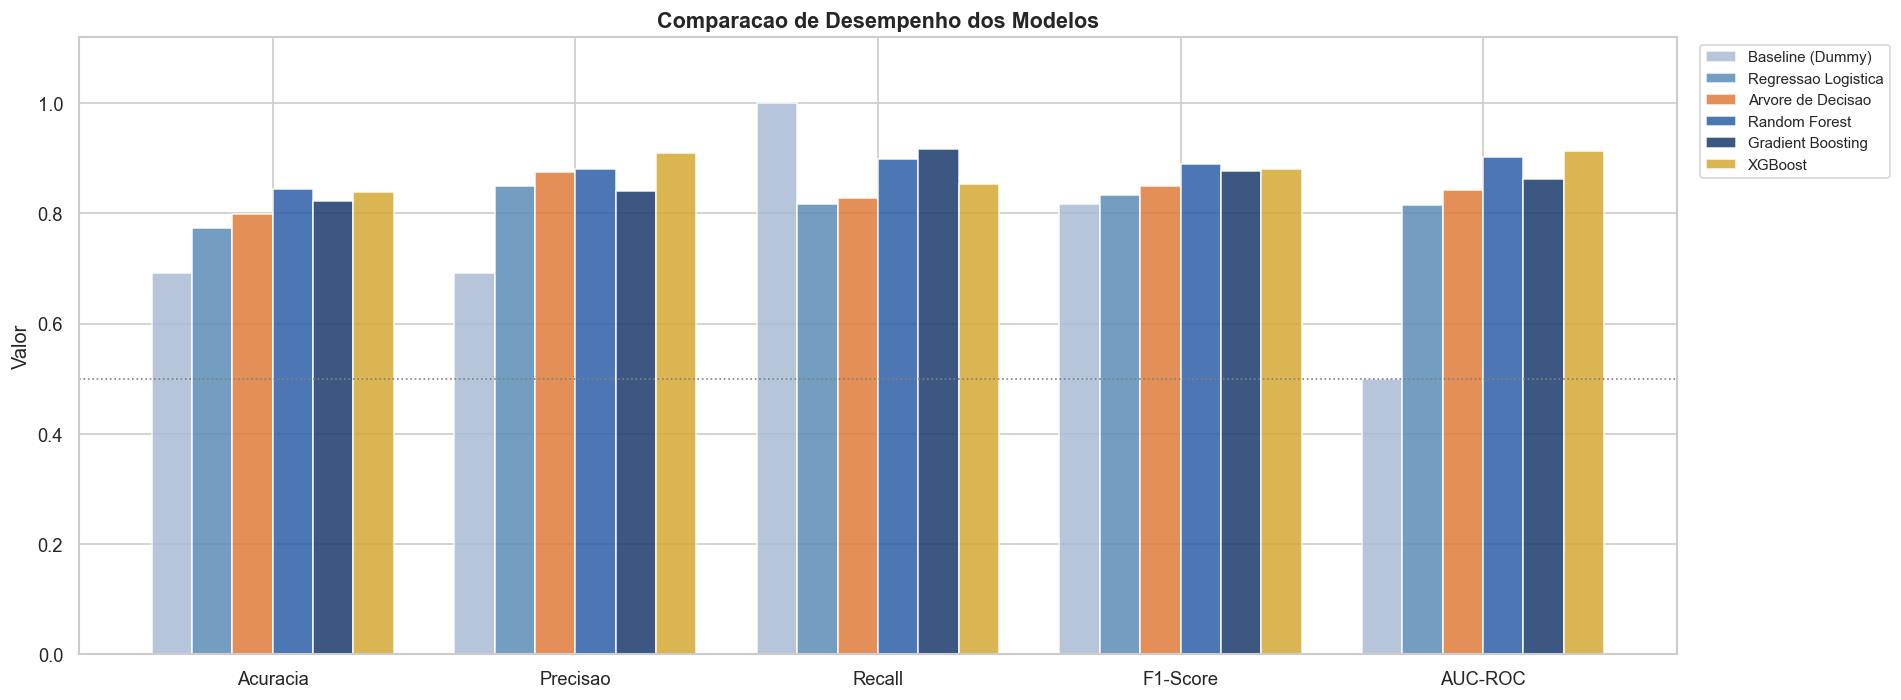

In [162]:
metricas = ['Acuracia', 'Precisao', 'Recall', 'F1-Score', 'AUC-ROC']
colors_modelos = ['#AABBD4', '#5B8DB8', '#E07B3A', '#2E5EA8', '#1A3A6B', '#D4A832']

n = len(df_resultados)
x = np.arange(len(metricas))
width = 0.8 / max(n, 1)

fig, ax = plt.subplots(figsize=(16, 6))

for i, (_, row) in enumerate(df_resultados.iterrows()):
    offset = (i - (n - 1) / 2) * width
    vals = [row[m] for m in metricas]
    ax.bar(
        x + offset,
        vals,
        width,
        label=row['Modelo'],
        color=colors_modelos[i % len(colors_modelos)],
        alpha=0.85,
    )

ax.set_xticks(x)
ax.set_xticklabels(metricas)
ax.set_ylim(0, 1.12)
ax.set_ylabel('Valor')
ax.set_title('Comparacao de Desempenho dos Modelos', fontweight='bold', fontsize=13)
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
ax.axhline(0.5, color='gray', linestyle=':', lw=1)

plt.tight_layout()
plt.savefig('fig11_comparacao_modelos.png', dpi=150, bbox_inches='tight')
plt.show()

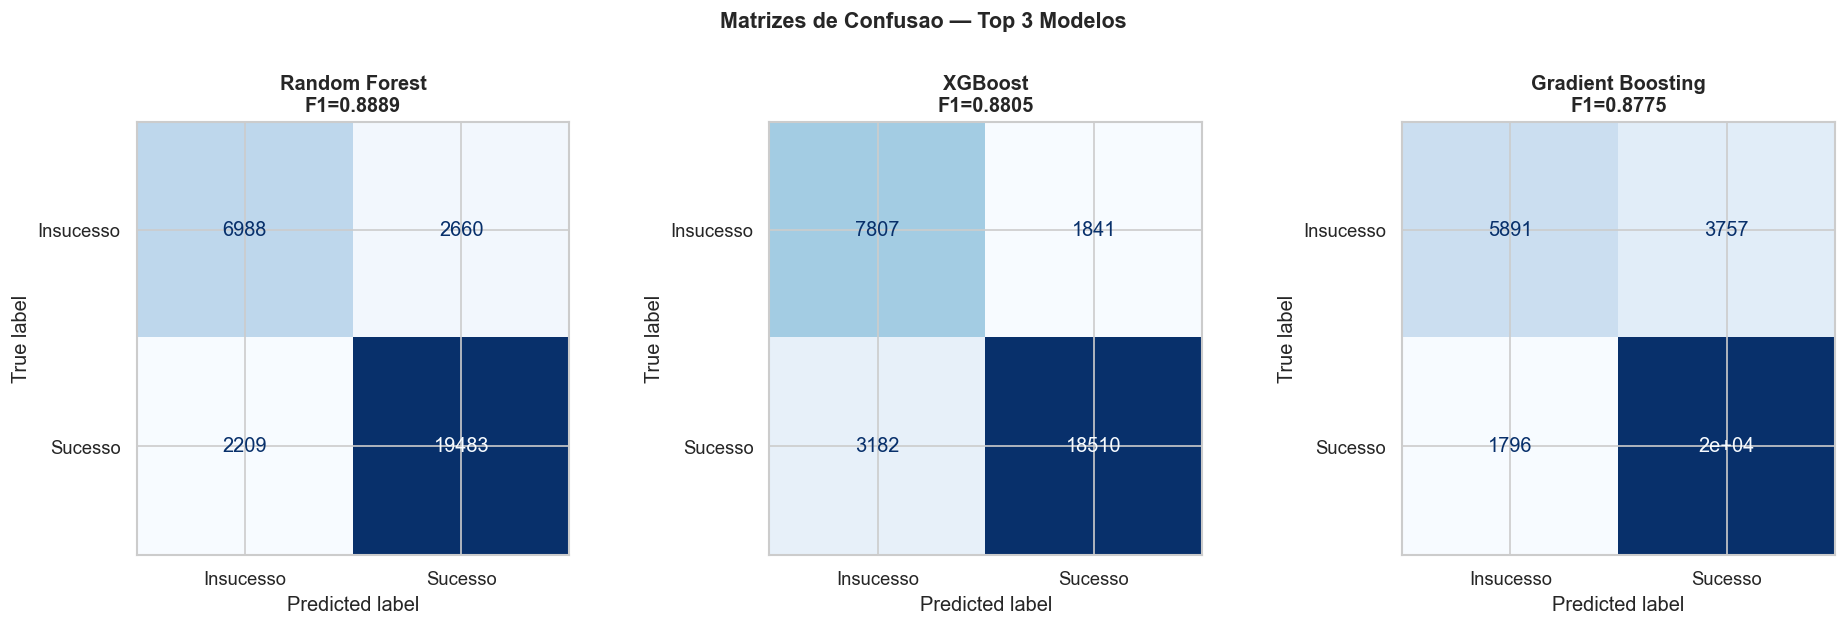

In [163]:
top3 = df_resultados.nlargest(3,'F1-Score')['Modelo'].tolist()
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, nome in zip(axes, top3):
    y_pred = pipelines_treinados[nome].predict(X_test)
    ConfusionMatrixDisplay(
        confusion_matrix(y_test, y_pred),
        display_labels=['Insucesso','Sucesso']
    ).plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{nome}\nF1={f1_score(y_test,y_pred,zero_division=0):.4f}', fontweight='bold')
plt.suptitle('Matrizes de Confusao — Top 3 Modelos', fontweight='bold', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('fig12_matrizes_confusao.png', dpi=150, bbox_inches='tight')
plt.show()

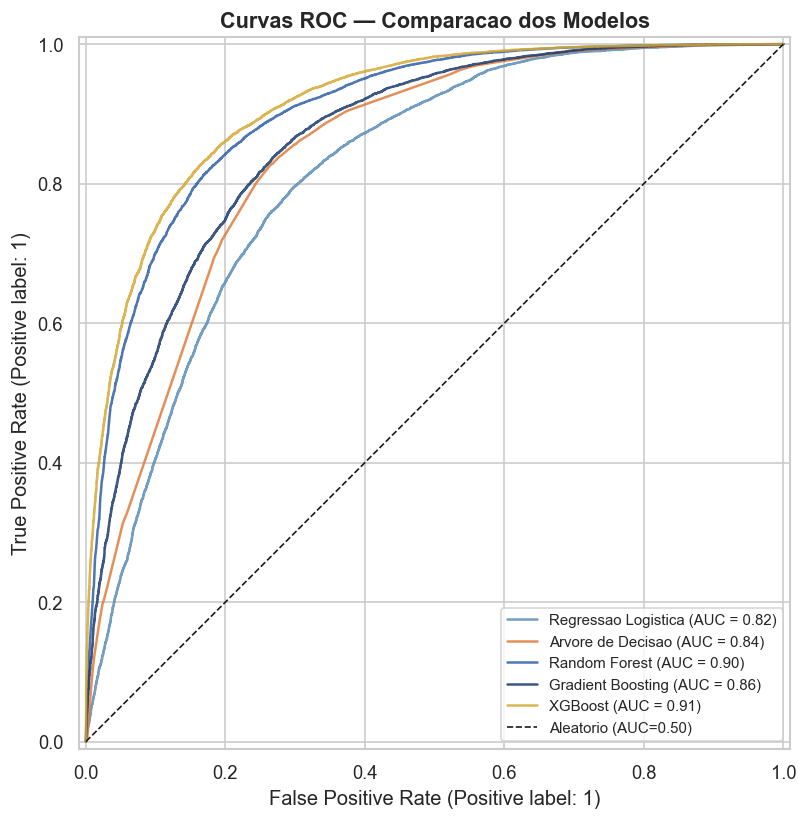

In [164]:
fig, ax = plt.subplots(figsize=(9, 7))
for i, (nome, pipe) in enumerate(pipelines_treinados.items()):
    if nome == 'Baseline (Dummy)': continue
    if hasattr(pipe.named_steps['classifier'], 'predict_proba'):
        RocCurveDisplay.from_estimator(pipe, X_test, y_test, ax=ax,
                                        name=nome, color=colors_modelos[i], alpha=0.85)
ax.plot([0,1],[0,1],'k--', lw=1, label='Aleatorio (AUC=0.50)')
ax.set_title('Curvas ROC — Comparacao dos Modelos', fontweight='bold', fontsize=13)
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.savefig('fig13_curvas_roc.png', dpi=150, bbox_inches='tight')
plt.show()

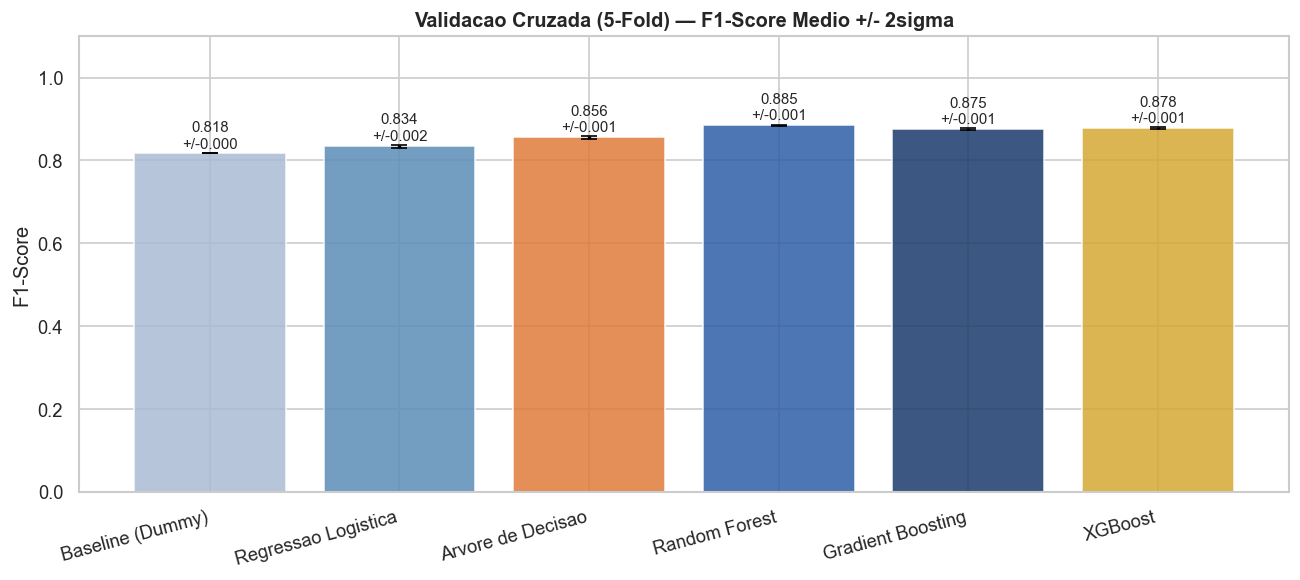

Melhor modelo: Random Forest
              precision    recall  f1-score   support

   Insucesso       0.76      0.72      0.74      9648
     Sucesso       0.88      0.90      0.89     21692

    accuracy                           0.84     31340
   macro avg       0.82      0.81      0.82     31340
weighted avg       0.84      0.84      0.84     31340



In [165]:
fig, ax = plt.subplots(figsize=(11, 5))
nomes  = df_resultados['Modelo']
medias = df_resultados['F1-CV Medio']
stds   = df_resultados['F1-CV Std']
bars = ax.bar(nomes, medias, color=colors_modelos[:len(nomes)], alpha=0.85)
ax.errorbar(nomes, medias, yerr=stds*2, fmt='none', color='black', capsize=5, lw=2)
for bar, val, std in zip(bars, medias, stds):
    ax.text(bar.get_x()+bar.get_width()/2, val+std*2+0.005,
            f'{val:.3f}\n+/-{std:.3f}', ha='center', va='bottom', fontsize=9)
ax.set_ylabel('F1-Score')
ax.set_title('Validacao Cruzada (5-Fold) — F1-Score Medio +/- 2sigma', fontweight='bold')
ax.set_ylim(0, 1.1)
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.savefig('fig14_cross_validation.png', dpi=150, bbox_inches='tight')
plt.show()

melhor = df_resultados.loc[df_resultados['F1-Score'].idxmax(), 'Modelo']
print(f'Melhor modelo: {melhor}')
print(classification_report(y_test, pipelines_treinados[melhor].predict(X_test),
                             target_names=['Insucesso','Sucesso']))

## 9. Interpretabilidade — Importância das Variáveis

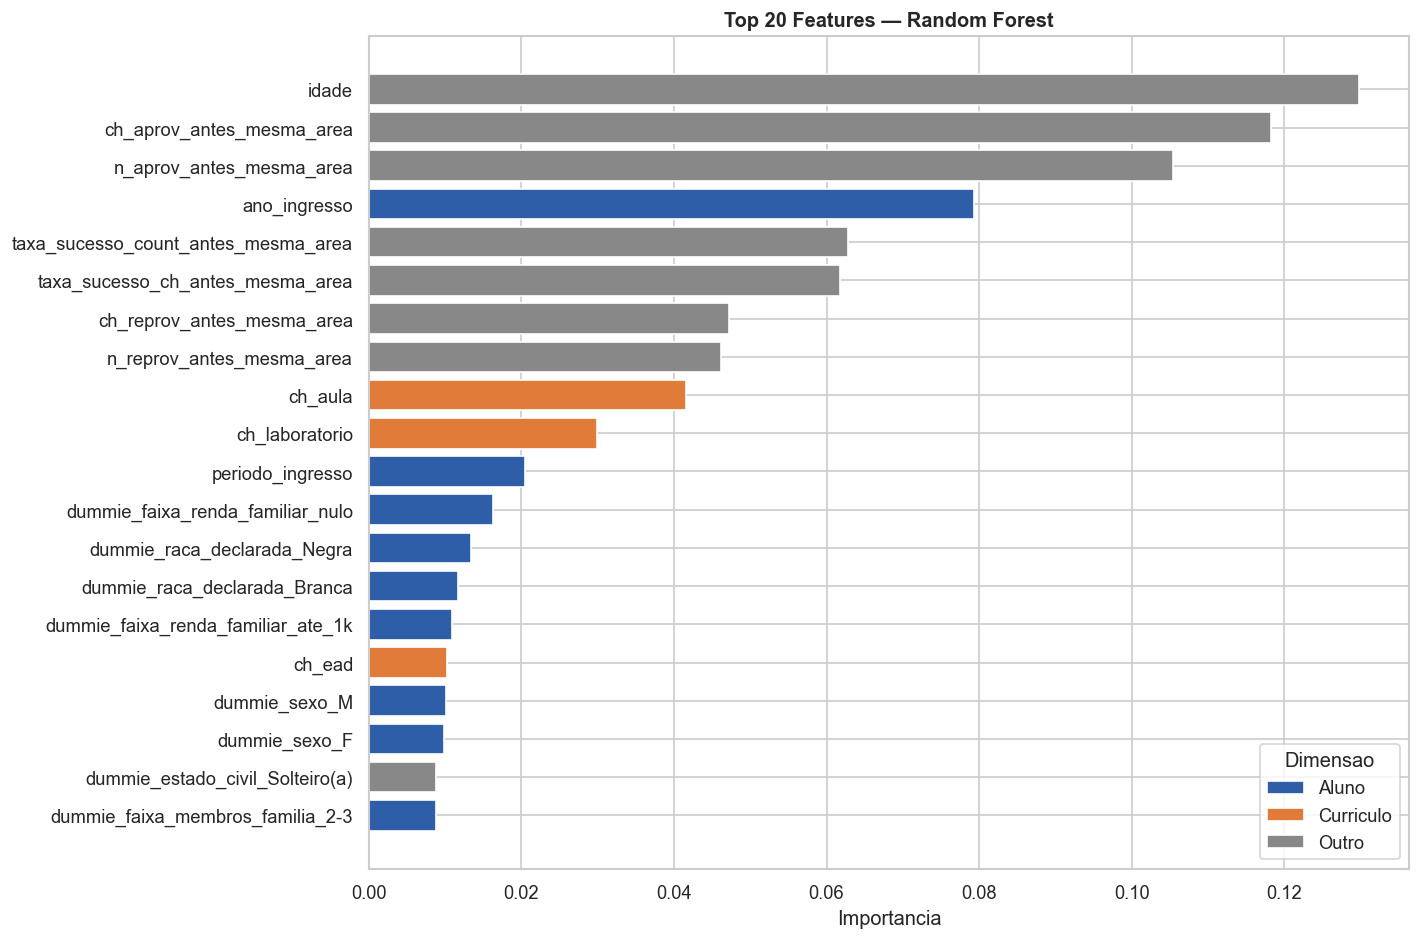


Top 10 features (Random Forest):
  [Outro     ] idade                                    0.1299
  [Outro     ] ch_aprov_antes_mesma_area                0.1183
  [Outro     ] n_aprov_antes_mesma_area                 0.1055
  [Aluno     ] ano_ingresso                             0.0793
  [Outro     ] taxa_sucesso_count_antes_mesma_area      0.0628
  [Outro     ] taxa_sucesso_ch_antes_mesma_area         0.0617
  [Outro     ] ch_reprov_antes_mesma_area               0.0472
  [Outro     ] n_reprov_antes_mesma_area                0.0462
  [Curriculo ] ch_aula                                  0.0416
  [Curriculo ] ch_laboratorio                           0.0299


In [166]:
modelos_arvore = ['Random Forest','XGBoost','Gradient Boosting','Arvore de Decisao']
nome_imp = next((m for m in modelos_arvore if m in pipelines_treinados), None)

if nome_imp:
    pipe_imp = pipelines_treinados[nome_imp]
    clf = pipe_imp.named_steps['classifier']
    prep = pipe_imp.named_steps['preprocessor']

    feat_names_all = FEAT_NUM.copy()
    if FEAT_CAT and 'cat' in prep.named_transformers_:
        ohe = prep.named_transformers_['cat'].named_steps['encoder']
        feat_names_all += list(ohe.get_feature_names_out(FEAT_CAT))

    df_imp = pd.DataFrame({'feature': feat_names_all, 'importancia': clf.feature_importances_})
    df_imp = df_imp.sort_values('importancia', ascending=False).head(20)

    def get_bloco(feat):
        f = feat.lower()
        if any(k in f for k in ['sexo','raca','renda','ingresso','familia','ch_integr','ch_pend','media_g','uf_','progress']):
            return 'Aluno'
        if any(k in f for k in ['ch_total','ch_aula','ch_lab','ch_ead','nivel','tipo_comp','qtd_max','campus','turno','prop_ch']):
            return 'Curriculo'
        if any(k in f for k in ['docentes','feminino','admissao','efetivo']):
            return 'Professor'
        return 'Outro'

    df_imp['bloco'] = df_imp['feature'].apply(get_bloco)
    bcolors = {'Aluno':'#2E5EA8','Curriculo':'#E07B3A','Professor':'#27A04B','Outro':'#888'}

    fig, ax = plt.subplots(figsize=(12, 8))
    ax.barh(df_imp['feature'][::-1], df_imp['importancia'][::-1],
            color=[bcolors[b] for b in df_imp['bloco']][::-1])
    ax.set_xlabel('Importancia')
    ax.set_title(f'Top 20 Features — {nome_imp}', fontweight='bold')
    ax.legend(handles=[Patch(facecolor=c, label=b) for b,c in bcolors.items()
                       if b in df_imp['bloco'].values], title='Dimensao')
    plt.tight_layout()
    plt.savefig('fig15_feature_importance.png', dpi=150, bbox_inches='tight')
    plt.show()

    print(f'\nTop 10 features ({nome_imp}):')
    for _, row in df_imp.head(10).iterrows():
        print(f'  [{row["bloco"]:10}] {row["feature"]:40} {row["importancia"]:.4f}')

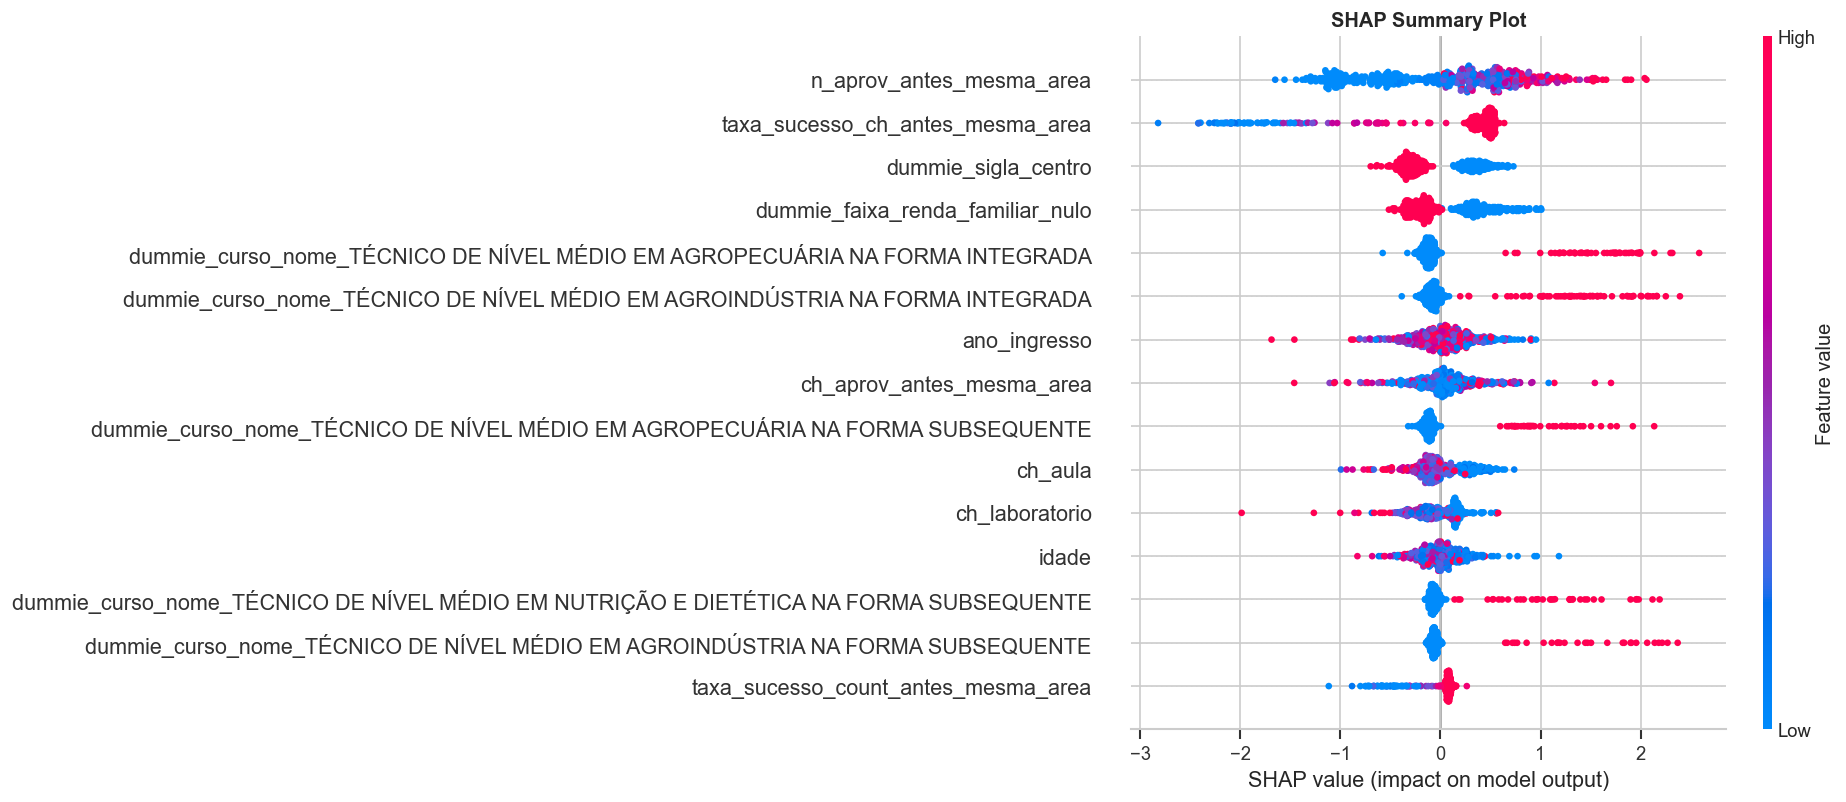

SHAP calculado com sucesso!


In [167]:
try:
    import shap
    pipe_shap = pipelines_treinados.get('XGBoost') or pipelines_treinados.get('Random Forest')
    X_shap = pipe_shap.named_steps['preprocessor'].transform(X_test)[:500]
    explainer   = shap.TreeExplainer(pipe_shap.named_steps['classifier'])
    shap_values = explainer.shap_values(X_shap)
    shap_vals   = shap_values[1] if isinstance(shap_values, list) else shap_values
    plt.figure(figsize=(11, 8))
    shap.summary_plot(shap_vals, X_shap, feature_names=feat_names_all, max_display=15, show=False)
    plt.title('SHAP Summary Plot', fontweight='bold')
    plt.tight_layout()
    plt.savefig('fig16_shap_summary.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('SHAP calculado com sucesso!')
except ImportError:
    print('SHAP nao instalado. Execute: pip install shap')
except Exception as e:
    print(f'SHAP indisponivel: {e}')

## 10. Conclusões Parciais e Próximos Passos

In [169]:
print('=' * 70)
print(' SUMARIO DOS RESULTADOS — ENTREGA PARCIAL')
print('=' * 70)
print(f'\nDataset integrado: {len(df_modelo):,} registros | {len(ALL_FEATURES)} features')
print('3 dimensoes: Aluno, Curriculo, Professor')
print('Variavel-alvo: Binaria (Sucesso / Insucesso)')
print('\nRanking dos modelos (F1-Score):')
df_rank = df_resultados[['Modelo','Acuracia','F1-Score','AUC-ROC','F1-CV Medio']]\
              .sort_values('F1-Score', ascending=False).reset_index(drop=True)
for idx, row in df_rank.iterrows():
    print(f'  {idx+1}. {row["Modelo"]:<25} F1={row["F1-Score"]:.4f}  AUC={row["AUC-ROC"]:.4f}  CV={row["F1-CV Medio"]:.4f}')

print('\nPrincipais observacoes EDA:')
print('  - Dimensao Aluno (renda, raca, forma de ingresso) apresenta variacao significativa na taxa de sucesso')
print('  - Diferenca de desempenho entre CPT-ETS (Joao Pessoa) e CAVN (Bananeiras)')
print('  - Componentes com alta proporcao de CH EaD mostram padrao distinto de aprovacao')
print('  - Departamentos diferem substancialmente em taxa de aprovacao')
print('  - media_geral e ch_integralizada sao os preditores mais fortes do perfil do aluno')

print('\nProximos passos (entrega final):')
print('  1. Otimizacao de hiperparametros (GridSearchCV / Optuna)')
print('  2. Tratamento de desbalanceamento (SMOTE)')
print('  3. Analise SHAP completa por dimensao')
print('  4. Validacao temporal (treinar em anos anteriores, testar no mais recente)')
print('  5. Analise de evasao como segunda variavel-alvo')
print('  6. Dashboard interativo com predicao em tempo real')

 SUMARIO DOS RESULTADOS — ENTREGA PARCIAL

Dataset integrado: 156,697 registros | 63 features
3 dimensoes: Aluno, Curriculo, Professor
Variavel-alvo: Binaria (Sucesso / Insucesso)

Ranking dos modelos (F1-Score):
  1. Random Forest             F1=0.8889  AUC=0.9024  CV=0.8854
  2. XGBoost                   F1=0.8805  AUC=0.9140  CV=0.8777
  3. Gradient Boosting         F1=0.8775  AUC=0.8633  CV=0.8754
  4. Arvore de Decisao         F1=0.8507  AUC=0.8433  CV=0.8556
  5. Regressao Logistica       F1=0.8334  AUC=0.8153  CV=0.8336
  6. Baseline (Dummy)          F1=0.8181  AUC=0.5000  CV=0.8181

Principais observacoes EDA:
  - Dimensao Aluno (renda, raca, forma de ingresso) apresenta variacao significativa na taxa de sucesso
  - Diferenca de desempenho entre CPT-ETS (Joao Pessoa) e CAVN (Bananeiras)
  - Componentes com alta proporcao de CH EaD mostram padrao distinto de aprovacao
  - Departamentos diferem substancialmente em taxa de aprovacao
  - media_geral e ch_integralizada sao os predit